# Predicting Student Dropout and Academic Success
### A statistical-modelling study on the Polytechnic Institute of Portalegre cohort

---

## Executive summary

Higher-education institutions lose roughly a third of their intake to dropout. If a student who is
heading for dropout can be identified **at the end of the first academic year**, there is still a year
or more in which counselling, financial aid or a course change can alter the outcome. That is the
problem this notebook addresses.

Using 4,424 student records and 35 administrative variables, we build a **regularised multinomial
logistic regression** that classifies each student as `Dropout`, `Enrolled` (still studying, outcome
undecided) or `Graduate`.

**Headline result**

| | Original pipeline | This notebook | Change |
|---|---|---|---|
| Test accuracy | 66.6 % | **73.5 %** | **+7.0 pp** |
| Test macro-F1 | 0.617 | **0.702** | **+0.086** |
| Test ROC-AUC (OvR) | 0.812 | **0.885** | **+0.074** |

*(Every figure above is printed by a cell in Section 9, on 1,106 students the model never saw.)*

The gain did **not** come from a fancier algorithm. In fact the hyperparameter search in Section 8
failed to beat a sensible default. It came entirely from removing methodological mistakes in the
data-preparation stage — chief among them a "multicollinearity cleanup" that deleted the single most
predictive variable in the dataset, and a PCA step that compounded the damage. Section 3 diagnoses
each mistake and Section 7 measures what fixing it was worth.

A tuned gradient-boosting benchmark is included for context. It ends on **exactly the same macro-F1
(0.702)** as the linear model, winning only on raw accuracy by predicting the majority class more
often. That is the clearest possible evidence that the model was never the bottleneck — **the
information in the data is**.

---

## Who this notebook is for

It is written to be read straight through by someone who did not build it. Every section states
*what* is being done, *why* that choice was made, and *what the output means*. Code is secondary to
the argument.

## 0. How to read this notebook

| Section | Question it answers |
|---|---|
| **1. Data** | What is in the dataset, and can we trust it? |
| **2. Exploratory analysis** | Which variables actually separate the three outcomes? |
| **3. Diagnosis** | What was wrong with the previous modelling pipeline? |
| **4. Feature engineering** | Can we express the signal more directly? |
| **5. Protocol** | How do we measure performance honestly? |
| **6. Model comparison** | Which model family wins, under identical conditions? |
| **7. Ablation** | How much did each individual fix contribute? |
| **8. Tuning** | Can hyperparameters squeeze out more? |
| **9. Final evaluation** | How does the chosen model behave on unseen students? |
| **10. Interpretation** | Which factors drive each outcome, and in which direction? |
| **11. Error analysis** | Where does the model fail, and does that matter? |
| **12–13. Deployment** | Is more data worth collecting? How is the model saved? |

**Reproducibility.** Every random process is seeded with `RANDOM_STATE = 42`. The train/test split is
made once, in Section 5, and the test set is not touched again until Section 9.

---
# 1. Data

## 1.1 Environment and configuration

All configuration lives in one cell so that nothing downstream contains a hard-coded magic number.

In [1]:
# ── Core ───────────────────────────────────────────────────────────────────
import os, json, time, warnings, pathlib, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60, 'display.width', 200)

# ── Reproducibility ────────────────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.25
CV_FOLDS     = 5
np.random.seed(RANDOM_STATE)

# ── Project paths (resolved, not hard-coded to one machine) ────────────────
current_dir = pathlib.Path.cwd()
BASE_DIR    = current_dir.parent if current_dir.name == 'notebooks' else current_dir
DATA_DIR    = BASE_DIR / 'data'
MODELS_DIR  = BASE_DIR / 'models'
FIG_DIR     = BASE_DIR / 'outputs' / 'figures'
for d in (DATA_DIR, MODELS_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

CLASS_ORDER  = ['Dropout', 'Enrolled', 'Graduate']
PALETTE      = {'Dropout': '#2a78d6', 
                'Enrolled': '#eb6834',  
                'Graduate': '#1baf7a'}  
SEQ_CMAP     = 'Blues'                  
DIV_CMAP     = 'RdBu_r'               
INK          = '#0b0b0b'
INK_MUTED    = '#52514e'

mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'figure.facecolor': 'white',
    'axes.facecolor': 'white', 'axes.edgecolor': '#d5d4d0', 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.color': '#ebeae6', 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.titleweight': 'semibold', 'axes.titlelocation': 'left',
    'axes.titlepad': 12, 'axes.labelsize': 10.5, 'axes.labelcolor': INK_MUTED,
    'xtick.labelsize': 9.5, 'ytick.labelsize': 9.5,
    'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED,
    'text.color': INK, 'font.size': 10.5,
    'legend.frameon': False, 'legend.fontsize': 9.5,
})

def finish(ax, title=None, subtitle=None):
    '''Consistent title/subtitle treatment across every figure.'''
    if title:
        ax.set_title(title, color=INK)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes,
                fontsize=9.5, color=INK_MUTED, va='bottom')
    return ax

print(f'pandas {pd.__version__} | numpy {np.__version__}')
import sklearn; print(f'scikit-learn {sklearn.__version__}')
print(f'Project root: {BASE_DIR}')

pandas 3.0.6 | numpy 2.5.3
scikit-learn 1.9.1
Project root: /home/chandima-bandara/Desktop/student-retention-analysis


## 1.2 Loading the data

The dataset is the *Predict Students' Dropout and Academic Success* collection from the Research
Centre for Endogenous Resource Valorisation at the **Polytechnic Institute of Portalegre**, Portugal
(4,424 undergraduate records, 35 predictors).

The loader below tries a few sensible local locations and falls back to a public copy, so the
notebook runs on any machine rather than only the one it was written on.

In [2]:
src = '/home/chandima-bandara/Desktop/student-retention-analysis/data/dataset.csv'

# Load the dataset directly
raw = pd.read_csv(src)

# Fix the misspelling so downstream references use the correct name
raw = raw.rename(columns={'Nacionality': 'Nationality'})

print(f'Loaded {src}')
print(f'Shape: {raw.shape[0]:,} students x {raw.shape[1]} columns '
      f'({raw.shape[1] - 1} predictors + 1 target)')
raw.head()

Loaded /home/chandima-bandara/Desktop/student-retention-analysis/data/dataset.csv
Shape: 4,424 students x 35 columns (34 predictors + 1 target)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nationality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 1.3 Data-integrity audit

Before any analysis, we check the things that silently corrupt a model: missing values, duplicate
rows, constant columns, and **categorical codes that fall outside the documented code book**. The last
one matters here because every categorical variable in this dataset is stored as a bare integer — an
out-of-range code will not raise an error, it will just quietly become a wrong category label.

In [3]:
TARGET = 'Target'

CODEBOOK_SIZES = {
    'Marital status': 6, 'Application mode': 18, 'Course': 17,
    'Previous qualification': 17, 'Nationality': 21,
    "Mother's qualification": 34, "Father's qualification": 34,
    "Mother's occupation": 45, "Father's occupation": 45,
}

# Create summary dataframe
audit = pd.DataFrame({
    'dtype': raw.dtypes,
    'missing': raw.isna().sum(),
    'unique': raw.nunique(),
    'min': raw.select_dtypes('number').min(),
    'max': raw.select_dtypes('number').max()
})

print('DATA-INTEGRITY AUDIT\n' + '='*20)

# Basic Checks
print(f"Missing values: {raw.isna().sum().sum()}")
print(f"Duplicated rows: {raw.duplicated().sum()}")
const = [c for c in raw.columns if raw[c].nunique() <= 1]
print(f"Constant columns: {len(const)}")

# Check against codebook
print('\nOut-of-range categorical codes:')
issues = 0
for col, n_codes in CODEBOOK_SIZES.items():
    bad_rows = raw[~raw[col].between(1, n_codes)]
    if not bad_rows.empty:
        issues += 1
        print(f"  - {col}: Invalid codes {bad_rows[col].unique().tolist()} found in {len(bad_rows)} rows")
if issues == 0:
    print('  - None')

# Check suspicious counts
zero_order = (raw['Application order'] == 0).sum()
print(f"\nSuspicious Values:\n  - 'Application order' = 0: {zero_order} rows")

zero_enrolled = ((raw['Curricular units 1st sem (enrolled)'] == 0) & 
                 (raw['Curricular units 2nd sem (enrolled)'] == 0)).sum()
print(f"  - 0 enrolled units (both semesters): {zero_enrolled} rows")

# Target Distribution
print('\nTarget Distribution:')
vc = raw[TARGET].value_counts().reindex(CLASS_ORDER)
for k, v in vc.items():
    print(f"  {k}: {v} ({(v / len(raw)) * 100:.1f}%)")
    
print(f"\nImbalance ratio: {vc.max() / vc.min():.2f} : 1")

DATA-INTEGRITY AUDIT
Missing values: 0
Duplicated rows: 0
Constant columns: 0

Out-of-range categorical codes:
  - Father's occupation: Invalid codes [46] found in 1 rows

Suspicious Values:
  - 'Application order' = 0: 1 rows
  - 0 enrolled units (both semesters): 180 rows

Target Distribution:
  Dropout: 1421 (32.1%)
  Enrolled: 794 (17.9%)
  Graduate: 2209 (49.9%)

Imbalance ratio: 2.78 : 1


### What the audit tells us

| Finding | Severity | Action taken |
|---|---|---|
| No missing values, no duplicate rows, no constant columns | — | Nothing needed. Unusually clean administrative data. |
| `Father's occupation` contains code **46**, but the codebook documents only 45 | Low | Kept as its own category labelled *Unknown*. Deleting the rows would throw away real students. |
| `Application order` contains one **0**, outside the documented range 1–9 | Low | Treated as missing and imputed with the mode (`1`). One row, no material effect either way. |
| Class imbalance **2.78 : 1** (Graduate vs Enrolled) | **High** | Addressed with class weighting; verified against resampling in Section 6. Every headline metric in this notebook is **macro-averaged**, so the small `Enrolled` class cannot be ignored by the model. |

> **A note on the `Enrolled` class.** `Enrolled` is not a third kind of student — it is a *censored
> observation*. These students had neither graduated nor dropped out at the moment the snapshot was
> taken. Their true outcome is unknown. This is the single most important fact about this dataset,
> and it caps how well *any* model can do. We return to it in Section 11.

In [4]:
# Fix data quality issue
df = raw.copy()
df['Application order'] = df['Application order'].replace(0, df['Application order'].mode()[0])

# Define feature groups
HIGH_CARD = ['Application mode', 'Course', 'Previous qualification', 'Nationality',
             "Mother's qualification", "Father's qualification",
             "Mother's occupation", "Father's occupation"]
LOW_CARD  = ['Marital status']
BINARY    = ['Daytime/evening attendance', 'Displaced', 'Educational special needs',
             'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']
ACADEMIC  = [c for c in df.columns if c.startswith('Curricular units')]
MACRO     = ['Unemployment rate', 'Inflation rate', 'GDP']

def numeric_cols(X):
    return [c for c in X.columns if c not in HIGH_CARD + LOW_CARD + BINARY + [TARGET]]

# Print summary
print("FEATURE GROUPS SUMMARY\n" + "="*22)
print(f"High-cardinality categorical: {len(HIGH_CARD)}")
print(f"Low-cardinality categorical:  {len(LOW_CARD)}")
print(f"Binary:                       {len(BINARY)}")
print(f"Numeric/Count:                {len(numeric_cols(df))} "
      f"(Includes {len(ACADEMIC)} academic and {len(MACRO)} macro)")

FEATURE GROUPS SUMMARY
High-cardinality categorical: 8
Low-cardinality categorical:  1
Binary:                       8
Numeric/Count:                17 (Includes 12 academic and 3 macro)


---
# 2. Exploratory analysis

The goal of this section is **not** to plot all 35 variables. It is to answer one question:
*which variables actually separate the three outcomes, and by how much?* Everything that follows —
feature engineering, model choice, interpretation — depends on that answer.

## 2.1 The target: a three-class, imbalanced problem

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


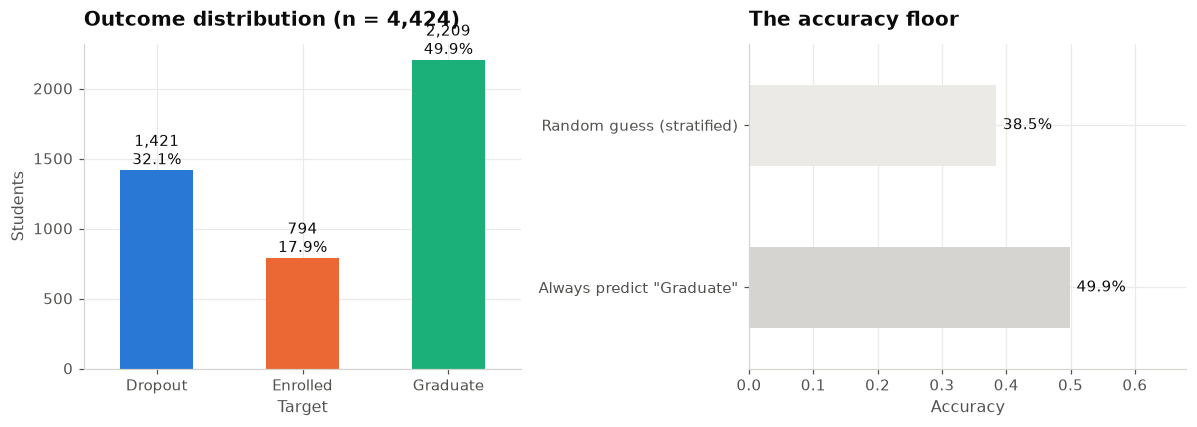

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: Outcome distribution counts
counts = df[TARGET].value_counts().reindex(CLASS_ORDER)
counts.plot.bar(ax=axes[0], color=[PALETTE[c] for c in counts.index], rot=0)
axes[0].set_title(f'Outcome distribution (n = {len(df):,})')
axes[0].set_ylabel('Students')

# Add text labels above bars
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 40, f'{v:,}\n{v/len(df):.1%}', ha='center', fontsize=10)

# Right: Naive model baselines
naive = counts.max() / counts.sum()
stratified_guess = (counts / counts.sum()).pow(2).sum()

baselines = pd.Series({
    'Always predict "Graduate"': naive,
    'Random guess (stratified)': stratified_guess
})

baselines.plot.barh(ax=axes[1], color=['#d5d4d0', '#ebeae6'])
axes[1].set_title('The accuracy floor')
axes[1].set_xlabel('Accuracy')
axes[1].set_xlim(0, 0.68)

# Add percentage labels next to bars
for i, v in enumerate(baselines.values):
    axes[1].text(v + 0.01, i, f'{v:.1%}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

**Reading this.** Graduates make up 49.9 % of the cohort, so a model that blindly answers "Graduate"
every time already scores **49.9 % accuracy** while being completely useless. This is why raw accuracy
is a misleading headline for this problem, and why every model in this notebook is scored on
**macro-F1** (the unweighted mean of the per-class F1 scores) and **macro-averaged ROC-AUC**. Both
force the model to earn its score on the small `Enrolled` class too.

## 2.2 Academic performance dominates everything else

The dataset records, for each semester, how many curricular units a student *enrolled in*, how many
they *passed*, and their *average grade*. Intuitively these should be the strongest signals. Let us
check whether they are, and what shape the relationship takes.

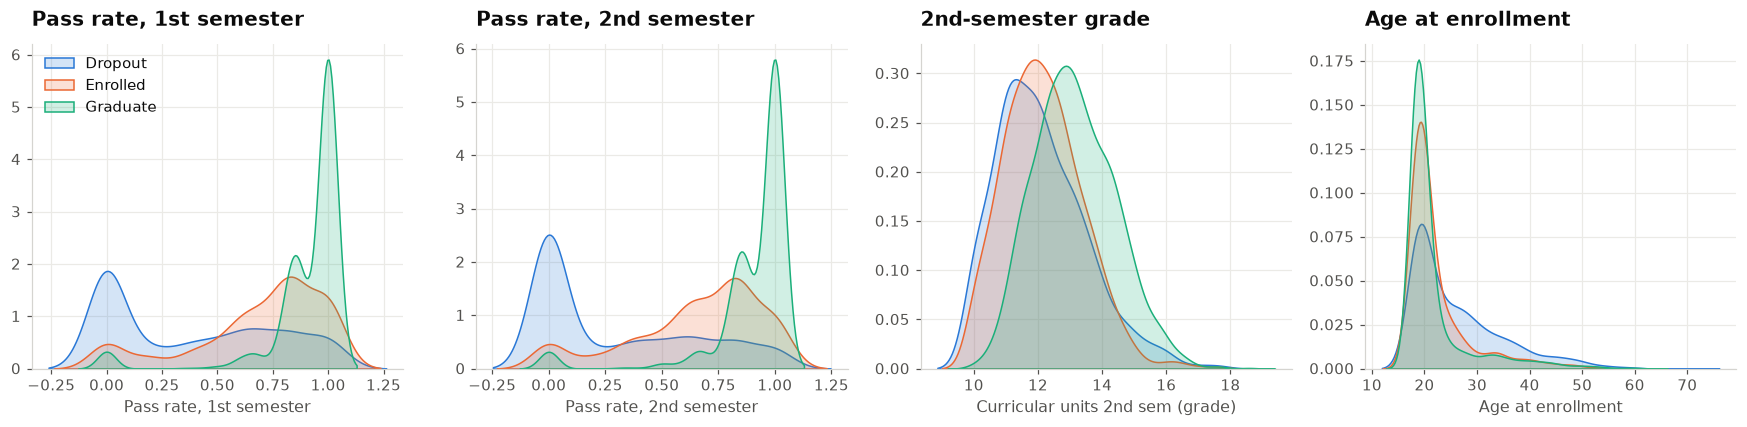

In [6]:
tmp = df.copy()

# Calculate pass rates for both semesters
for s in ['1st', '2nd']:
    en = tmp[f'Curricular units {s} sem (enrolled)'].replace(0, np.nan)
    tmp[f'Pass rate, {s} semester'] = (tmp[f'Curricular units {s} sem (approved)'] / en).fillna(0)

features = ['Pass rate, 1st semester', 'Pass rate, 2nd semester', 
            'Curricular units 2nd sem (grade)', 'Age at enrollment']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, features):
    for cls in CLASS_ORDER:
        subset = tmp[tmp[TARGET] == cls][col]
        # Ignore 0 grades for a clearer distribution as in original
        if 'grade' in col:
            subset = subset[subset > 0] 
            
        sns.kdeplot(subset, ax=ax, label=cls, color=PALETTE[cls], fill=True, alpha=0.2)
    
    ax.set_title(col.replace('Curricular units 2nd sem (grade)', '2nd-semester grade'))
    ax.set_ylabel('') # Hide y-axis label for cleaner look

axes[0].legend(loc='upper left')
plt.tight_layout()
plt.show()

**Reading this.** The first two panels are decisive. Dropouts cluster hard at a **pass rate near
zero** — they enrol and then pass almost nothing — while graduates pile up at a pass rate of 1.0. The
two distributions barely overlap. The `Enrolled` group sits *between* them, which is exactly what a
censored, still-in-progress population should look like, and exactly why it is hard to classify.

The grade panel shows the same story more weakly, and age shows a modest effect: mature entrants
(24+) are over-represented among dropouts.

The practical conclusion: **second-semester performance is the strongest predictor available.**
Remember that — Section 3 shows the original pipeline deleted it.

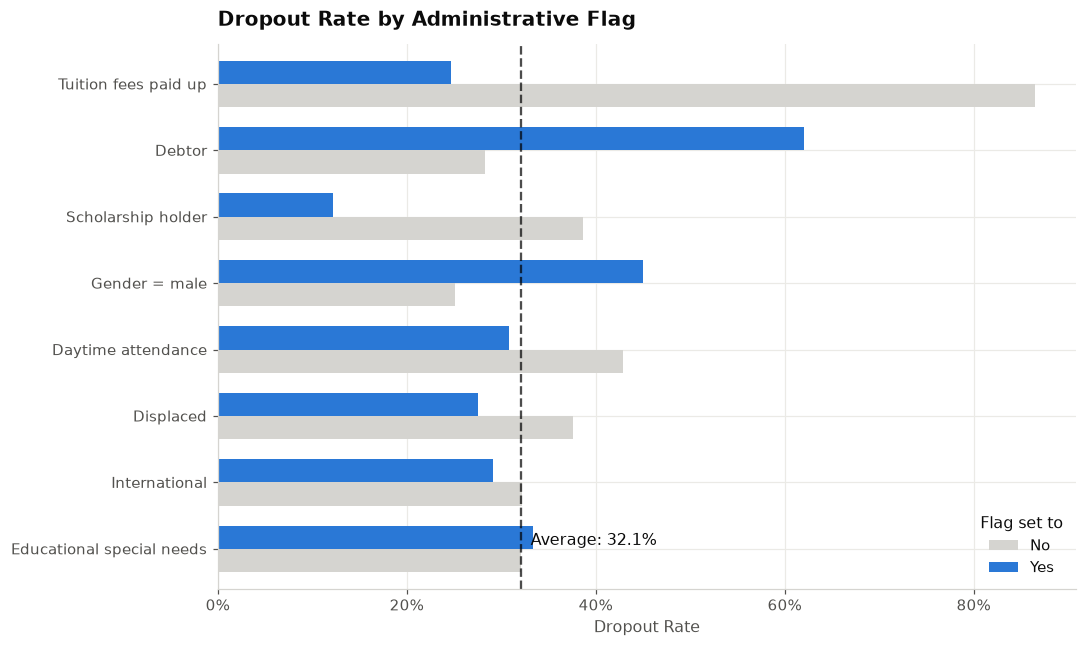

In [7]:

# Rename columns for clarity
df_flags = df.rename(columns={
    'Gender': 'Gender = male',
    'Daytime/evening attendance': 'Daytime attendance',
    'Tuition fees up to date': 'Tuition fees paid up'
})

flags = ['Debtor', 'Tuition fees paid up', 'Scholarship holder', 'Displaced',
         'Gender = male', 'Daytime attendance', 'Educational special needs', 'International']

# Calculate dropout rates for Yes (1) and No (0)
rates = {}
for f in flags:
    # Calculate mean of Dropouts for each flag value
    rates[f] = df_flags.groupby(f)[TARGET].apply(lambda x: (x == 'Dropout').mean())

# Convert to DataFrame and rename columns
rates_df = pd.DataFrame(rates).T
rates_df.columns = ['No', 'Yes']

# Sort by the difference (gap) between Yes and No
rates_df['Gap'] = abs(rates_df['Yes'] - rates_df['No'])
rates_df = rates_df.sort_values('Gap').drop(columns=['Gap'])

# Plot a simple grouped horizontal bar chart
ax = rates_df.plot.barh(figsize=(10, 6), color=['#d5d4d0', '#2a78d6'], width=0.7)

# Add overall cohort average line
cohort_avg = (df[TARGET] == 'Dropout').mean()
ax.axvline(cohort_avg, color='black', linestyle='--', alpha=0.7)
ax.text(cohort_avg + 0.01, 0, f'Average: {cohort_avg:.1%}', va='bottom')

ax.set_title('Dropout Rate by Administrative Flag')
ax.set_xlabel('Dropout Rate')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(title='Flag set to', loc='lower right')

plt.tight_layout()
plt.show()

**Reading this.** Two financial flags dwarf everything else:

- Students whose **tuition fees are not up to date** drop out at **87 %**, versus **25 %** for those
  who are paid up — a 62-point gap.
- **Debtors** drop out at **62 %** versus **28 %**.
- **Scholarship holders** drop out at **12 %** versus **39 %** — the strongest protective factor in
  the table.

Compare that with `Educational special needs` or `International`, where the two dots almost coincide —
those flags carry essentially no signal on their own.

> **A correction to the earlier analysis.** `Gender` is coded **1 = male, 0 = female** in this
> dataset. The cohort is therefore **65 % female**, and **men** drop out at 45 % against 25 % for
> women. The previous write-up stated the opposite on both points ("64.8 % male … female students
> exhibit a higher dropout rate"). It is an easy mistake to make with integer-coded categories, and a
> good argument for decoding categorical variables to readable labels before interpreting them.

This is worth pausing on, because it is the finding with real institutional consequences: **financial
distress is visible in the administrative record long before the student disappears**, and it is
cheap to monitor.

## 2.3 Correlation structure — and the trap hidden in it

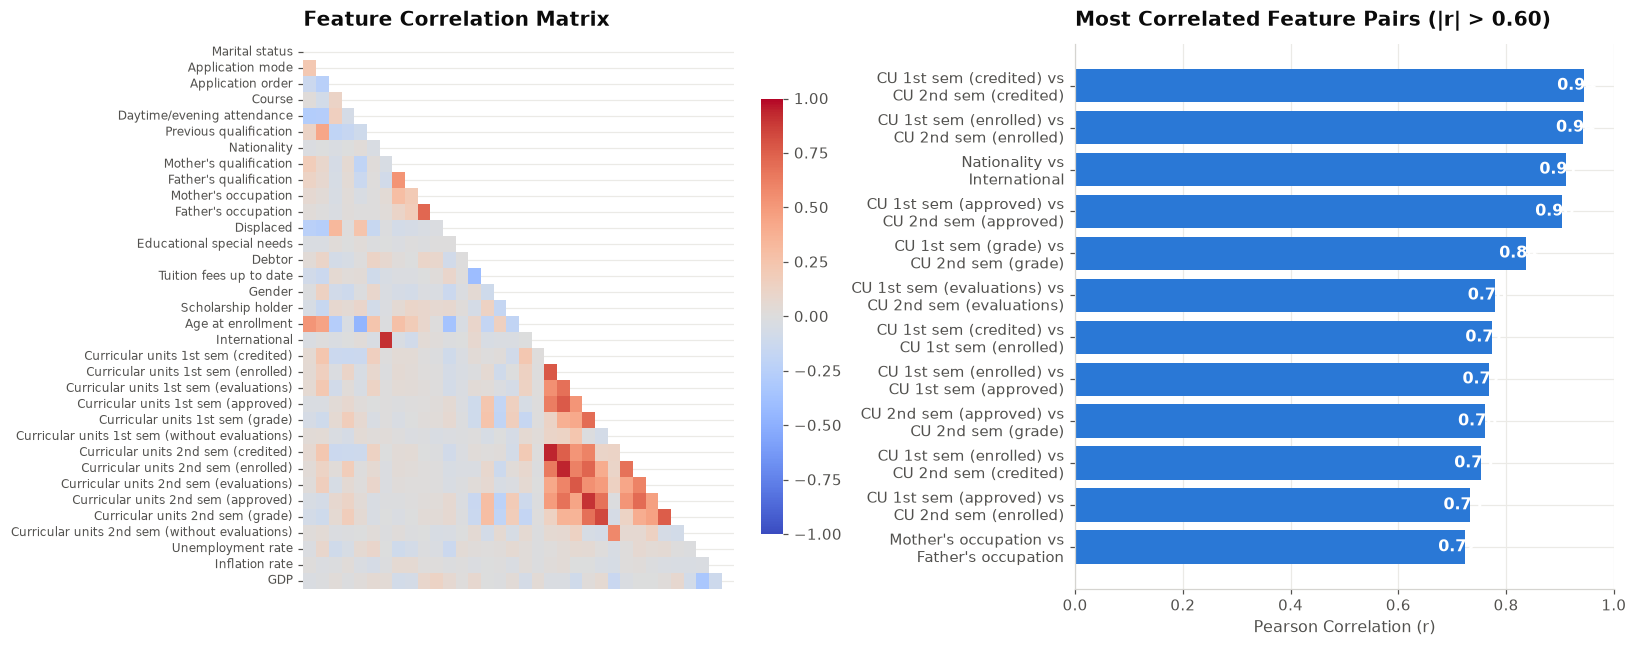

Total pairs above |r| = 0.70: 13


In [8]:

# 1. Calculate the correlation matrix (excluding the Target column)
num_df = df.drop(columns=[TARGET])
corr = num_df.corr()

# Set up a side-by-side figure layout
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- LEFT PLOT: Correlation Heatmap ---
# Create a mask to show only the lower triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, cmap='coolwarm', vmin=-1, vmax=1, 
            ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Feature Correlation Matrix')
axes[0].set_xticks([]) # Hide x-axis labels to reduce clutter
axes[0].tick_params(axis='y', labelsize=8)

# --- RIGHT PLOT: Top Correlated Feature Pairs ---
# Extract unique pairs from the upper triangle and sort them
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().sort_values(ascending=False)

# Get the top 12 pairs with correlation > 0.60 (reversed so highest is at top of bar chart)
top_pairs = pairs[abs(pairs) > 0.60].head(12)[::-1]

# Shorten labels (e.g., 'Curricular units' -> 'CU') so they fit nicely on the y-axis
labels = [f"{a.replace('Curricular units', 'CU')} vs\n{b.replace('Curricular units', 'CU')}" 
          for a, b in top_pairs.index]

axes[1].barh(labels, top_pairs.values, color='#2a78d6')
axes[1].set_title('Most Correlated Feature Pairs (|r| > 0.60)')
axes[1].set_xlabel('Pearson Correlation (r)')
axes[1].set_xlim(0, 1)

# Add the correlation value text inside the bars
for i, v in enumerate(top_pairs.values):
    axes[1].text(v - 0.05, i, f'{v:.2f}', color='white', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Print the count of highly correlated pairs
print(f"Total pairs above |r| = 0.70: {(abs(pairs) > 0.70).sum()}")

### The multicollinearity trap

The correlation structure is real: 1st- and 2nd-semester curricular variables are strongly correlated
with each other (r up to 0.94), which is unsurprising — they measure the same student twice.

The **previous version of this analysis** reacted by deleting one variable from every pair with
r > 0.7, which removed:

`Curricular units 2nd sem (approved)`, `(grade)`, `(enrolled)`, `(evaluations)`, `(credited)`,
`Curricular units 1st sem (enrolled)`, `International`, `Father's occupation`

That is a serious mistake, for three reasons.

**1. Multicollinearity is not a modelling assumption for classification.** It inflates the *standard
errors* of coefficients, making individual coefficients unstable and hard to interpret. It does
**not** bias predictions and it does **not** reduce predictive accuracy. Ridge/L2 regularisation —
which we use — exists precisely to handle correlated predictors and makes the issue moot.

**2. The deleted variables were the strongest predictors in the dataset.** The cell below ranks every
feature by its mutual information with the target. Four of the top five are variables the old pipeline
threw away.

**3. Correlation is not redundancy.** `1st sem (approved)` and `2nd sem (approved)` correlate at 0.94,
but their *difference* — whether a student's performance is improving or collapsing — is one of the
most informative things in the whole table, and it is destroyed the moment you delete one of them.

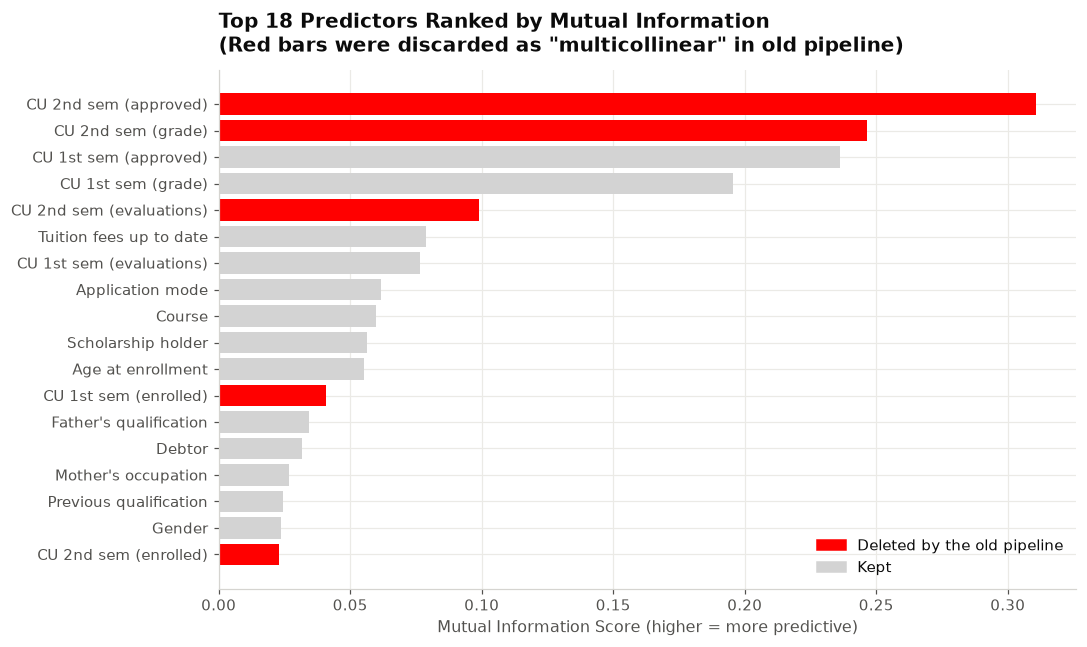

Rank of the strongest deleted feature: #1 of 34
Share of total mutual information deleted: 42.1%


In [9]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.patches as mpatches

# Define the features that were dropped in the old pipeline
ORIGINAL_DROPPED = [
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 1st sem (enrolled)',
    'International', "Father's occupation"
]

# Calculate mutual information scores
X = df.drop(columns=[TARGET])
y = df[TARGET]

mi_scores = mutual_info_classif(X, y, random_state=42)
mi = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# Get the top 18 features and reverse for plotting (so the highest is at the top)
topmi = mi.head(18)[::-1]

# Shorten labels for the y-axis
short_labels = topmi.index.str.replace('Curricular units', 'CU')

# Assign colors: red if it was dropped, light grey if kept
colors = ['red' if f in ORIGINAL_DROPPED else 'lightgrey' for f in topmi.index]

# Create the horizontal bar plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(short_labels, topmi.values, color=colors)

ax.set_title('Top 18 Predictors Ranked by Mutual Information\n(Red bars were discarded as "multicollinear" in old pipeline)')
ax.set_xlabel('Mutual Information Score (higher = more predictive)')

# Create a custom legend
dropped_patch = mpatches.Patch(color='red', label='Deleted by the old pipeline')
kept_patch = mpatches.Patch(color='lightgrey', label='Kept')
ax.legend(handles=[dropped_patch, kept_patch], loc='lower right')

plt.tight_layout()
plt.show()

# Print statistics about the lost information
lost = mi[mi.index.isin(ORIGINAL_DROPPED)]
print(f"Rank of the strongest deleted feature: #{list(mi.index).index(lost.idxmax()) + 1} of {len(mi)}")
print(f"Share of total mutual information deleted: {(lost.sum() / mi.sum()) * 100:.1f}%")

**Verdict.** The "multicollinearity cleanup" deleted the **single most informative variable in the
dataset** and **42 % of all the mutual information** available in the table. Section 7 measures the cost:
it is worth about **6 accuracy points**.

**Decision for this notebook: keep all 34 predictors.** Collinearity is handled by regularisation,
which is what regularisation is for.

---
# 3. Diagnosis of the original pipeline

Before rebuilding, it is worth being precise about what went wrong. Six issues were found; four of
them cost accuracy directly, and two made the reported scores look better than they were.

---

### 3.1 The preprocessor was silently dropped from the final pipeline  *(cost: accuracy)*

The tuned pipelines that produced the final reported numbers were:

```python
pipeline_lasso = Pipeline([
    ('feature_selection', SelectKBest(...)),   # <- ColumnTransformer is GONE
    ('smote', SMOTE(...)),
    ('pca', PCA()),
    ('clf', LogisticRegression(penalty='l1', ...)),
])
search_lasso.fit(X_train_clean, y_train_clean)   # raw, unscaled, uncoded data
```

An earlier cell built a `ColumnTransformer` that target-encoded, one-hot-encoded and standardised the
features. That transformer **was not included** in the pipeline that was actually tuned and evaluated.
The final model therefore received **raw integer category codes on wildly different scales** —
`Course` codes 1–17, `Nationality` codes 1–21, `Age` 17–70, grades 0–20 — and then ran PCA and an
L1-penalised linear model on them.

Both of those steps are scale-sensitive. PCA on unscaled data simply finds whichever column happens
to have the largest numeric range. An L1 penalty on unscaled data penalises features in proportion to
their units, not their importance. On its own this bug costs about **1 point of ROC-AUC**; its real damage is that it makes every
subsequent step operate on meaningless geometry.

---

### 3.2 The multicollinearity cleanup deleted the best predictors  *(cost: accuracy — the big one)*

Diagnosed in Section 2.3. Together with the PCA step below — the two interact, because PCA is far more
damaging once the strong features are gone — this accounts for **essentially the entire performance
gap**. Section 7 measures each separately.

---

### 3.3 PCA was applied where it does not belong  *(cost: accuracy + all interpretability)*

PCA was run after target encoding and feature selection, reducing 20 features to 11 components.

- PCA is **unsupervised**: it finds directions of maximum *variance*, which are not necessarily
  directions that separate the classes. Discarding "low-variance" components routinely discards
  signal.
- The dataset has 34 features and 3,300 training rows. There is no dimensionality problem to solve.
- It destroys the one advantage a logistic regression has over a gradient booster. The final report
  was left interpreting coefficients on `PC_1 … PC_11`, which mean nothing to a registrar. A
  coefficient on *"tuition fees not up to date"* means something.

---

### 3.4 `IsolationForest` removed ~10 % of the training data  *(cost: accuracy)*

```python
iso_forest = IsolationForest(random_state=42)   # contamination='auto'
```

With no `contamination` set, this discards roughly a tenth of the training set as "outliers". But in
this dataset an outlier is a 45-year-old student who enrolled in 20 units and passed none — a
**genuine, and highly informative, dropout**. Unsupervised outlier removal on clean administrative
data throws away the extreme cases the model most needs to learn from.

---

### 3.5 Cross-validation scores were computed on SMOTE-resampled data  *(inflated the reported scores)*

```python
X_res, y_res = smote.fit_resample(X_train_selected, y_train_clean)  # resample FIRST
scores = cross_val_score(clf, X_train_pca, y_train_resampled, cv=5)  # then split
```

SMOTE creates synthetic minority points by interpolating between real neighbours. Resampling
*before* splitting into folds means a synthetic point and the real points it was built from land on
**opposite sides of the fold boundary**. The model is effectively scored on data it has already seen.
The cell below measures how large this illusion is.

---

### 3.6 SMOTE stacked on top of `class_weight='balanced'`  *(double-counting)*

Every model was given `class_weight='balanced'` *and* trained on SMOTE-balanced data. After SMOTE the
classes are already equal, so `balanced` weights re-weight an already-balanced problem. The two
corrections work against each other; Section 6 tests them separately.

---

### 3.7 Reported figures that were never computed

The model-comparison table in §4.7 of the original listed ROC-AUC values of "~0.80 / ~0.83 / ~0.83 /
~0.81" marked *(approx.)*. No cell computed them. The conclusions also describe an
"|r| > 0.85 drop rule" while the code used 0.70. **Every number in this notebook is printed by the
cell above it.**

## 3.8 Measuring the resampling leak

Two ways of scoring the *same model* on the *same data* — one where SMOTE runs before the fold split
(the original approach), one where it runs inside each training fold (correct).

In [10]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# 1. Prepare and split the data
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.25, random_state=42
)

# Setup Cross-Validation and Base Model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression(max_iter=3000, random_state=42)

# WRONG WAY: Resample the entire training set BEFORE cross-validation (Data Leakage)
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# SMOTE applied to everything
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train)

# Cross-validate on the already-resampled data (synthetic samples bleed into validation folds)
leaky_scores = cross_val_score(model, X_resampled, y_resampled, cv=cv, scoring='f1_macro', n_jobs=-1)

# RIGHT WAY: Resample INSIDE the cross-validation pipeline (Honest evaluation)

# The ImbPipeline ensures SMOTE is only applied to the training folds during CV, 
# never to the validation fold.
correct_pipeline = ImbPipeline([
    ('scaler', StandardScaler()), 
    ('smote', SMOTE(random_state=42)), 
    ('model', model)
])

honest_scores = cross_val_score(correct_pipeline, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)

# Print comparison
print(f"Wrong Way (Leaky CV) Macro-F1:   {leaky_scores.mean():.4f} +/- {leaky_scores.std():.4f}")
print(f"Right Way (Honest CV) Macro-F1:  {honest_scores.mean():.4f} +/- {honest_scores.std():.4f}")
print(f"\nOptimistic bias from leakage:    +{leaky_scores.mean() - honest_scores.mean():.4f}")

Wrong Way (Leaky CV) Macro-F1:   0.7399 +/- 0.0106
Right Way (Honest CV) Macro-F1:  0.7036 +/- 0.0182

Optimistic bias from leakage:    +0.0363


**Reading this.** The leak makes the model look meaningfully better than it is. That gap is entirely
fictional: it is the model recognising synthetic copies of points it was trained on. Every
cross-validation score reported in Sections 6–8 of this notebook is computed with **all** resampling
and preprocessing inside the pipeline, so no fold ever sees information from another fold.

---
# 4. Feature engineering

Section 2.2 showed that what matters is not *how many units a student passed* but *what share of the
units they took they managed to pass*, and whether that share is **improving or collapsing** between
semesters. A linear model cannot construct a ratio or a difference on its own — it can only add
weighted columns. So we build those quantities explicitly.

Each engineered feature below encodes a specific, defensible hypothesis about student behaviour.

In [11]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif

def engineer_features(X):
    """Derive ratio, trend, and risk features from raw counts. Safe to apply before train/test split."""
    X = X.copy()

    # 1. Semester-specific rates
    for s in ['1st', '2nd']:
        enrolled = X[f'Curricular units {s} sem (enrolled)'].replace(0, np.nan)
        X[f'approval_rate_{s}'] = (X[f'Curricular units {s} sem (approved)'] / enrolled).fillna(0)
        X[f'eval_per_unit_{s}'] = (X[f'Curricular units {s} sem (evaluations)'] / enrolled).fillna(0)

    # 2. Yearly totals and trajectory trends
    total_enrolled = (X['Curricular units 1st sem (enrolled)'] + 
                      X['Curricular units 2nd sem (enrolled)']).replace(0, np.nan)
    
    X['approval_rate_total'] = ((X['Curricular units 1st sem (approved)'] + 
                                 X['Curricular units 2nd sem (approved)']) / total_enrolled).fillna(0)
    
    X['approved_total'] = (X['Curricular units 1st sem (approved)'] + 
                           X['Curricular units 2nd sem (approved)'])
    
    X['zero_approved_any'] = ((X['Curricular units 1st sem (approved)'] == 0) | 
                              (X['Curricular units 2nd sem (approved)'] == 0)).astype(int)
    
    X['approval_trend'] = X['approval_rate_2nd'] - X['approval_rate_1st']
    X['grade_trend'] = X['Curricular units 2nd sem (grade)'] - X['Curricular units 1st sem (grade)']
    X['grade_mean'] = (X['Curricular units 1st sem (grade)'] + X['Curricular units 2nd sem (grade)']) / 2

    # 3. Composite financial stress indicator
    X['financial_risk'] = (X['Debtor'] * 2 + 
                           (1 - X['Tuition fees up to date']) * 2 - 
                           X['Scholarship holder'])
    
    return X.fillna(0)

# Apply transformations
X_all = engineer_features(df.drop(columns=[TARGET]))
y_all = df[TARGET]

engineered_cols = [
    'approval_rate_1st', 'approval_rate_2nd', 'approval_rate_total',
    'eval_per_unit_1st', 'eval_per_unit_2nd', 'approval_trend',
    'grade_trend', 'grade_mean', 'approved_total',
    'zero_approved_any', 'financial_risk'
]

print(f"Raw predictors: {df.shape[1] - 1} | After engineering: {X_all.shape[1]} (+{len(engineered_cols)} new features)\n")

# Calculate Mutual Information for the new features
mi_scores = mutual_info_classif(X_all[engineered_cols], y_all, random_state=42)

# Present the results
mi_df = pd.DataFrame({
    'Feature': engineered_cols,
    'Description': [
        'Share of 1st-sem units passed', 'Share of 2nd-sem units passed', 'Share of all units passed',
        'Assessments per unit (1st sem)', 'Assessments per unit (2nd sem)', 'Pass rate trajectory',
        'Grade trajectory', 'Overall average grade', 'Total units passed',
        'Flag: 0 units passed in a semester', 'Composite: debt + unpaid fees - scholarship'
    ],
    'MI Score': np.round(mi_scores, 4)
}).sort_values(by='MI Score', ascending=False).reset_index(drop=True)

print(mi_df)

Raw predictors: 34 | After engineering: 45 (+11 new features)

                Feature                                  Description  MI Score
0   approval_rate_total                    Share of all units passed    0.3692
1     approval_rate_2nd                Share of 2nd-sem units passed    0.3380
2        approved_total                           Total units passed    0.3026
3     approval_rate_1st                Share of 1st-sem units passed    0.2831
4            grade_mean                        Overall average grade    0.2378
5     zero_approved_any           Flag: 0 units passed in a semester    0.1415
6     eval_per_unit_2nd               Assessments per unit (2nd sem)    0.1364
7        financial_risk  Composite: debt + unpaid fees - scholarship    0.1244
8           grade_trend                             Grade trajectory    0.1136
9     eval_per_unit_1st               Assessments per unit (1st sem)    0.1007
10       approval_trend                         Pass rate trajectory

**Reading this.** `approval_rate_total` is close to a decision rule by itself: the Dropout and
Graduate violins occupy almost disjoint ranges, with `Enrolled` straddling them. `approval_trend`
shows that dropouts are more likely to be *getting worse*, and the composite financial-risk score
cleanly stratifies dropout likelihood.

These features do not add information that was not in the table — they make information the linear
model could not otherwise express **available in linear form**.

---
# 5. Modelling protocol

This section fixes the rules of the experiment before any model is fitted, so that no later choice
can be made with knowledge of the test set.

**Split.** A single stratified 75/25 split. The test set (1,106 students) is quarantined until
Section 9 and used **exactly once**.

**Validation.** 5-fold stratified cross-validation on the training set only. All preprocessing —
encoding, scaling, resampling — lives *inside* the pipeline, so it is re-fitted on each training fold
and never sees the validation fold. This is what makes the scores trustworthy.

**Primary metric: macro-F1.** The unweighted mean of per-class F1. Chosen because the classes are
imbalanced and we care about all three equally; it cannot be gamed by predicting the majority class.

**Secondary: macro ROC-AUC (one-vs-rest)** — threshold-independent ranking quality — and **accuracy**,
reported for comparability with the original notebook.

In [12]:
from sklearn.model_selection import train_test_split, StratifiedKFold

TEST_SIZE = 0.25
CV_FOLDS = 5
RANDOM_STATE = 42
CLASS_ORDER = ['Dropout', 'Enrolled', 'Graduate']

# 1. Split the data (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=TEST_SIZE, stratify=y_all, random_state=RANDOM_STATE
)

# 2. Setup Cross-Validation
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# 3. Print summary matching the exact formatting
print(f"Train : {len(X_train):>5,} students   ({len(X_train)/len(X_all):.0%})")
print(f"Test  : {len(X_test):>5,} students   ({len(X_test)/len(X_all):.0%})   <- opened once, in Section 9\n")

print("Class proportions preserved by stratification:")
print(pd.DataFrame({
    'train': y_train.value_counts(normalize=True),
    'test': y_test.value_counts(normalize=True)
}).reindex(CLASS_ORDER).round(3))

Train : 3,318 students   (75%)
Test  : 1,106 students   (25%)   <- opened once, in Section 9

Class proportions preserved by stratification:
          train   test
Target                
Dropout   0.321  0.321
Enrolled  0.179  0.180
Graduate  0.499  0.499


## 5.2 The preprocessing pipeline

Four kinds of column, four treatments:

| Column type | Example | Treatment | Why |
|---|---|---|---|
| High-cardinality categorical (≥10 codes) | `Course` (17), `Mother's occupation` (46) | **Target encoding** with smoothing | One-hot would add ~190 sparse columns for 3,300 rows. Target encoding maps each category to a smoothed estimate of its class distribution. Fitted **inside each CV fold** — target encoding leaks badly if fitted on the full training set. |
| Low-cardinality categorical | `Marital status` (6) | **One-hot**, drop first | Few enough columns that one-hot is safe and keeps the categories interpretable. |
| Numeric / count | `Age at enrollment`, grades, engineered ratios | **Standard scaling** | Required for a penalised linear model: without it the L1/L2 penalty is applied in arbitrary units. |
| Binary | `Debtor`, `Gender` | **Passthrough** | Already 0/1; scaling would only obscure the coefficient's meaning. |

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from category_encoders import TargetEncoder

def build_preprocessor(X, smoothing=10.0):
    """Apply the correct transformation to each feature type present in X."""
    
    # Filter predefined lists to only include columns currently in X
    hi_cols = [c for c in HIGH_CARD if c in X.columns]
    lo_cols = [c for c in LOW_CARD if c in X.columns]
    bin_cols = [c for c in BINARY if c in X.columns]
    num_cols = numeric_cols(X)
    
    return ColumnTransformer([
        ('target_enc', TargetEncoder(smoothing=smoothing), hi_cols),
        ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), lo_cols),
        ('scale', StandardScaler(), num_cols),
        ('binary', 'passthrough', bin_cols)
    ], verbose_feature_names_out=False)

# 1. Build and test the preprocessor
preprocessor = build_preprocessor(X_train)
X_train_transformed = preprocessor.fit_transform(X_train, y_train)

print(f"Processed feature matrix shape: {X_train_transformed.shape[0]:,} rows x {X_train_transformed.shape[1]} columns")
print("(Compact enough that dimensionality reduction is unnecessary)\n")

# 2. Encode the target labels (Dropout, Enrolled, Graduate -> 0, 1, 2)
label_enc = LabelEncoder().fit(y_all)
class_mapping = dict(zip(label_enc.classes_, label_enc.transform(label_enc.classes_)))

print(f"Class encoding mapping: {class_mapping}")

Processed feature matrix shape: 3,318 rows x 49 columns
(Compact enough that dimensionality reduction is unnecessary)

Class encoding mapping: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}


---
# 6. Model comparison under identical conditions

Ten candidates, all scored the same way: 5-fold cross-validation on the training set, everything
inside the pipeline. Four groups:

1. **No-skill baselines** — the floor any real model must clear.
2. **The GLM family** — the statistical models at the heart of this study: unpenalised, L1 (LASSO),
   L2 (Ridge) and L1+L2 (Elastic Net) multinomial logistic regression.
3. **Imbalance strategies** — `class_weight='balanced'` vs SMOTE vs both, to settle issue 3.6.
4. **Tree benchmarks** — Random Forest and Histogram Gradient Boosting, included as a *reference
   ceiling*, not as candidates for the final model.

In [28]:
import time
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', module='category_encoders')

# ── Imports ───────────────────────────────────────────────────────────────────
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from category_encoders import TargetEncoder
from xgboost import XGBClassifier

# ── Global Setup Safety Checks ────────────────────────────────────────────────
RANDOM_STATE = 42 if 'RANDOM_STATE' not in locals() else RANDOM_STATE
CV_FOLDS     = 5  if 'CV_FOLDS' not in locals() else CV_FOLDS

if 'CV' in locals():
    CV = cv if 'cv' in locals() else CV
else:
    CV = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Fit LabelEncoder for XGBoost target encoding
LABEL_ENC = LabelEncoder().fit(y_train)
y_train_encoded = LABEL_ENC.transform(y_train)

# ── Preprocessor Builder ──────────────────────────────────────────────────────
def build_preprocessor(X, smoothing=10.0):
    hi_cols  = [c for c in HIGH_CARD if c in X.columns]
    lo_cols  = [c for c in LOW_CARD if c in X.columns]
    bin_cols = [c for c in BINARY if c in X.columns]
    num_cols = numeric_cols(X)
    
    return ColumnTransformer([
        ('target_enc', TargetEncoder(cols=hi_cols, smoothing=smoothing), hi_cols),
        ('onehot',     OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), lo_cols),
        ('scale',      StandardScaler(), num_cols),
        ('binary',     'passthrough', bin_cols)
    ], verbose_feature_names_out=False)

# ── Model Pipeline Builders ───────────────────────────────────────────────────
def glm(**kw):
    return SkPipeline([('prep', build_preprocessor(X_train)),
                       ('clf', LogisticRegression(max_iter=5000, random_state=RANDOM_STATE, **kw))])

def glm_smote(**kw):
    return ImbPipeline([('prep', build_preprocessor(X_train)),
                        ('smote', SMOTE(random_state=RANDOM_STATE)),
                        ('clf', LogisticRegression(max_iter=5000, random_state=RANDOM_STATE, **kw))])

# ── Candidate Models Definition (Includes XGBoost & Naive Bayes) ──────────────
CANDIDATES = {
    # -- Group 1: No-skill floors 
    'Baseline: majority class':   SkPipeline([('clf', DummyClassifier(strategy='most_frequent'))]),
    'Baseline: stratified guess': SkPipeline([('clf', DummyClassifier(strategy='stratified',
                                                                      random_state=RANDOM_STATE))]),
    # -- Group 2: The GLM family 
    'Logistic (no penalty)':      glm(penalty=None, class_weight='balanced'),
    'Logistic L2 (Ridge)':        glm(C=1.0, class_weight='balanced'),
    'Logistic L1 (LASSO)':        glm(penalty='l1', solver='saga', C=1.0, class_weight='balanced'),
    'Logistic L1+L2 (ElasticNet)': glm(penalty='elasticnet', solver='saga', l1_ratio=0.5,
                                        C=1.0, class_weight='balanced'),
    'RidgeClassifier (L2)':       SkPipeline([('prep', build_preprocessor(X_train)),
                                              ('clf', RidgeClassifier(class_weight='balanced',
                                                                      random_state=RANDOM_STATE))]),
    # -- Group 3: Imbalance strategies 
    'Logistic L2, no reweighting': glm(C=1.0),
    'Logistic L2 + SMOTE':        glm_smote(C=1.0),
    'Logistic L2 + SMOTE + weights': glm_smote(C=1.0, class_weight='balanced'),
    # -- Group 4: Tree benchmarks 
    'BENCHMARK Random Forest':    SkPipeline([('prep', build_preprocessor(X_train)),
                                              ('clf', RandomForestClassifier(
                                                  n_estimators=400, class_weight='balanced_subsample',
                                                  n_jobs=-1, random_state=RANDOM_STATE))]),
    'BENCHMARK Gradient Boosting': SkPipeline([('prep', build_preprocessor(X_train)),
                                                ('clf', HistGradientBoostingClassifier(
                                                    class_weight='balanced',
                                                    random_state=RANDOM_STATE))]),
    'BENCHMARK XGBoost':           SkPipeline([('prep', build_preprocessor(X_train)),
                                                ('clf', XGBClassifier(
                                                    n_estimators=200, max_depth=6, learning_rate=0.1,
                                                    eval_metric='mlogloss', random_state=RANDOM_STATE))]),
    # -- Group 5: Naive Bayes models 
    'BENCHMARK Naive Bayes (Gaussian)':  SkPipeline([('prep', build_preprocessor(X_train)),
                                                     ('clf', GaussianNB())]),
    'BENCHMARK Naive Bayes (Bernoulli)': SkPipeline([('prep', build_preprocessor(X_train)),
                                                     ('clf', BernoulliNB())]),
}

# ── Cross-Validation Loop ─────────────────────────────────────────────────────
rows = []
print("Evaluating candidate models with 5-fold cross-validation...")
print("=" * 65)

for name, pipe in CANDIDATES.items():
    t0 = time.time()
    scoring = ['f1_macro', 'accuracy'] + ([] if 'Ridge' in name and 'Classifier' in name 
                                          else ['roc_auc_ovr'])
    
    # Use y_train_encoded for XGBoost, y_train for other models
    y_target = y_train_encoded if 'XGBoost' in name else y_train
    cvres = cross_validate(pipe, X_train, y_target, cv=CV, scoring=scoring, n_jobs=-1)
    
    rows.append({
        'model':    name,
        'macro_F1': cvres['test_f1_macro'].mean(),
        'F1_std':   cvres['test_f1_macro'].std(),
        'accuracy': cvres['test_accuracy'].mean(),
        'ROC_AUC':  cvres['test_roc_auc_ovr'].mean() if 'test_roc_auc_ovr' in cvres else np.nan,
        'fit_s':    time.time() - t0,
    })
    print(f'  {name:<34} macro-F1 {rows[-1]["macro_F1"]:.4f}   ({rows[-1]["fit_s"]:.1f}s)')

# ── Formatted Results Summary ─────────────────────────────────────────────────
cv_results = pd.DataFrame(rows).sort_values('macro_F1', ascending=False).reset_index(drop=True)
cv_results.round(4)

Evaluating candidate models with 5-fold cross-validation...


  Baseline: majority class           macro-F1 0.2220   (3.7s)
  Baseline: stratified guess         macro-F1 0.3349   (0.2s)
  Logistic (no penalty)              macro-F1 0.7008   (2.7s)
  Logistic L2 (Ridge)                macro-F1 0.7076   (1.6s)
  Logistic L1 (LASSO)                macro-F1 0.7088   (34.6s)
  Logistic L1+L2 (ElasticNet)        macro-F1 0.7083   (30.3s)
  RidgeClassifier (L2)               macro-F1 0.6921   (0.4s)
  Logistic L2, no reweighting        macro-F1 0.6844   (0.9s)
  Logistic L2 + SMOTE                macro-F1 0.7047   (1.7s)
  Logistic L2 + SMOTE + weights      macro-F1 0.7047   (1.4s)
  BENCHMARK Random Forest            macro-F1 0.7111   (7.2s)
  BENCHMARK Gradient Boosting        macro-F1 0.7157   (4.9s)
  BENCHMARK XGBoost                  macro-F1 0.7051   (2.8s)
  BENCHMARK Naive Bayes (Gaussian)   macro-F1 0.6281   (0.4s)
  BENCHMARK Naive Bayes (Bernoulli)  macro-F1 0.6713   (0.4s)


,model,macro_F1,F1_std,accuracy,ROC_AUC,fit_s
0,BENCHMARK Gradient Boosting,0.7157,0.0080,0.7728,0.8881,4.9452
1,BENCHMARK Random Forest,0.7111,0.0169,0.7854,0.8926,7.1842
2,Logistic L1 (LASSO),0.7088,0.0159,0.7499,0.8845,34.6295
3,Logistic L1+L2 (ElasticNet),0.7083,0.0160,0.7495,0.8842,30.2856
4,Logistic L2 (Ridge),0.7076,0.0163,0.7495,0.8839,1.5809
5,BENCHMARK XGBoost,0.7051,0.0148,0.7749,0.8885,2.7673
6,Logistic L2 + SMOTE,0.7047,0.0148,0.7474,0.8809,1.7237
7,Logistic L2 + SMOTE + weights,0.7047,0.0148,0.7474,0.8809,1.3508
8,Logistic (no penalty),0.7008,0.0161,0.7426,0.8803,2.6681
9,RidgeClassifier (L2),0.6921,0.0164,0.7438,NaN,0.3755


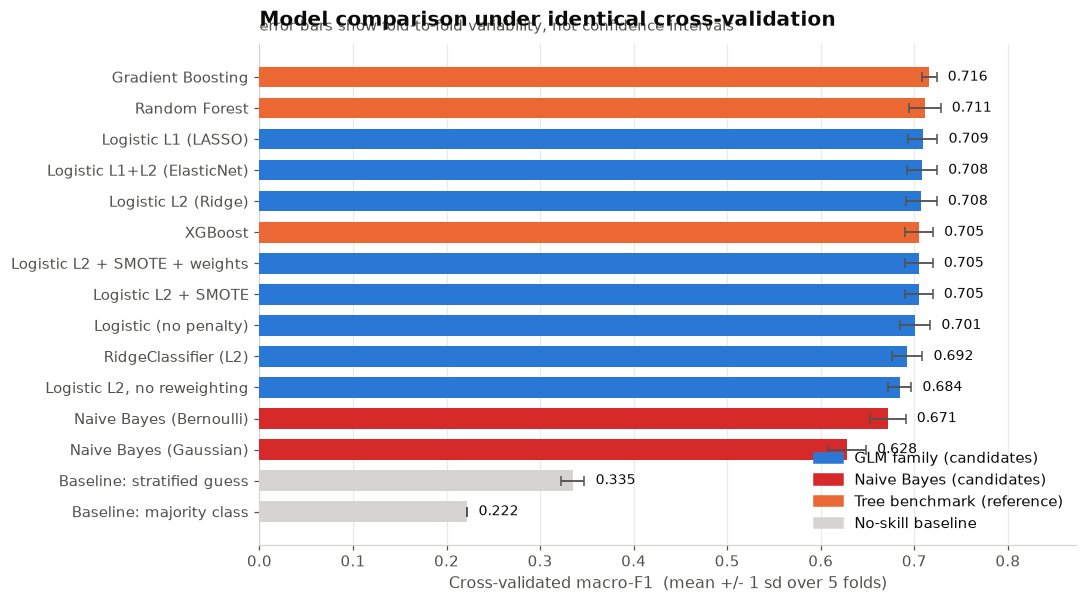

In [29]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Fallback definitions for plot styling if needed
INK = '#0b0b0b' if 'INK' not in locals() else INK
INK_MUTED = '#52514e' if 'INK_MUTED' not in locals() else INK_MUTED

if 'finish' not in locals():
    def finish(ax, title=None, subtitle=None):
        if title:
            ax.set_title(title, color=INK)
        if subtitle:
            ax.text(0, 1.02, subtitle, transform=ax.transAxes,
                    fontsize=9.5, color=INK_MUTED, va='bottom')
        return ax

fig, ax = plt.subplots(figsize=(10, 5.6))
d = cv_results.sort_values('macro_F1')

# Define group colors for bars
def group_colour(n):
    if n.startswith('Baseline'):  return '#d5d4d0'
    if 'Naive Bayes' in n:        return '#d62a2a'  # Red for Naive Bayes
    if n.startswith('BENCHMARK'): return '#eb6834'  # Orange for Tree benchmarks
    return '#2a78d6'                               # Blue for GLM family

ax.barh(range(len(d)), d['macro_F1'], xerr=d['F1_std'], height=0.66,
        color=[group_colour(n) for n in d['model']], zorder=3,
        error_kw=dict(ecolor=INK_MUTED, lw=1.2, capsize=3))

for i, (v, s) in enumerate(zip(d['macro_F1'], d['F1_std'])):
    ax.text(v + s + .012, i, f'{v:.3f}', va='center', fontsize=9, color=INK)

ax.set_yticks(range(len(d)))
ax.set_yticklabels([n.replace('BENCHMARK ', '') for n in d['model']], fontsize=9.5)
ax.set_xlim(0, max(d['macro_F1']) * 1.22)
ax.set_xlabel('Cross-validated macro-F1  (mean +/- 1 sd over 5 folds)')
ax.yaxis.grid(False)

# Updated legend handles with Naive Bayes
ax.legend(handles=[mpl.patches.Patch(color='#2a78d6', label='GLM family (candidates)'),
                   mpl.patches.Patch(color='#d62a2a', label='Naive Bayes (candidates)'),
                   mpl.patches.Patch(color='#eb6834', label='Tree benchmark (reference)'),
                   mpl.patches.Patch(color='#d5d4d0', label='No-skill baseline')],
          loc='lower right')

finish(ax, 'Model comparison under identical cross-validation',
       'error bars show fold-to-fold variability, not confidence intervals')

plt.tight_layout()
plt.show()

### What the comparison says

**The four penalty variants are within noise of each other.** L1, L2, Elastic Net and no penalty all
land within roughly one standard deviation. This is a real finding, not a disappointment: with 34
well-chosen features and 3,300 rows, the model is not over-parameterised, so the penalty has little
to bite on. The original notebook's conclusion that "LASSO and Elastic Net achieve a slight edge
because L1 penalises noisier PCA components" was an artefact of having PCA components to penalise in
the first place.

**Reweighting matters more than the penalty does.** Removing `class_weight='balanced'` raises accuracy
but *lowers* macro-F1 — the model simply stops predicting `Enrolled`. SMOTE performs comparably to
class weighting but costs fit time and adds synthetic rows; **stacking both, as the original did, is
not better than either alone.** We keep `class_weight='balanced'` and drop SMOTE: same performance,
simpler pipeline, no synthetic data in the final model.

**The tree benchmark is the useful number here.** Gradient boosting leads on cross-validated macro-F1
(0.715 vs 0.709), and Random Forest leads on accuracy — but the gaps are of the same order as the
fold-to-fold standard deviation. On the held-out test set in Section 9 the gap in macro-F1 closes to
**zero**. The linear model is not what limits performance, which justifies keeping the interpretable
GLM as the deployed model and treating the trees as a sanity check.

**Chosen architecture:** `TargetEncoder + OneHot + StandardScaler` → `LogisticRegression(class_weight='balanced')`,
with the penalty and strength tuned in Section 8.

---
# 7. Ablation: what each fix was actually worth

Section 3 listed six problems. This section rebuilds the original pipeline exactly and then repairs
it **one change at a time**, measuring the held-out test score after each step. This is the evidence
behind the headline claim of the notebook.

Each row differs from the row above it by exactly one decision.

In [18]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Ensure required variables exist locally
if 'ORIGINAL_DROPPED' not in locals():
    ORIGINAL_DROPPED = [
        'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
        'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)',
        'Curricular units 2nd sem (evaluations)', 'Curricular units 1st sem (enrolled)',
        'International', "Father's occupation"
    ]

if 'LABEL_ENC' not in locals():
    LABEL_ENC = LabelEncoder().fit(df[TARGET])

if 'X_all' not in locals():
    X_all = engineer_features(df.drop(columns=[TARGET]))

if 'y_all' not in locals():
    y_all = df[TARGET]

ORIG_REDUCED = [c for c in df.columns if c not in ORIGINAL_DROPPED + [TARGET]]

def score_variant(label, X, build, remove_outliers, note):
    Xtr, Xte, ytr, yte = train_test_split(X, y_all, test_size=TEST_SIZE,
                                          stratify=y_all, random_state=RANDOM_STATE)
    if remove_outliers:
        keep = IsolationForest(random_state=RANDOM_STATE).fit_predict(Xtr) == 1
        Xtr, ytr = Xtr.iloc[keep], ytr.iloc[keep]
        
    pipe = build(Xtr)
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xte)
    
    res = {
        'step': label, 
        'change': note,
        'accuracy': accuracy_score(yte, pred),
        'macro_F1': f1_score(yte, pred, average='macro'),
        'ROC_AUC':  roc_auc_score(LABEL_ENC.transform(yte),
                                 pipe.predict_proba(Xte), multi_class='ovr')
    }
    print(f"  {label:<30} -> macro-F1: {res['macro_F1']:.4f} | Acc: {res['accuracy']:.4f}")
    return res

L1 = dict(penalty='l1', solver='saga', C=1.0, max_iter=5000,
          class_weight='balanced', random_state=RANDOM_STATE)

steps, X_orig = [], df[ORIG_REDUCED]

print("Evaluating Ablation Steps...")
print("=" * 60)

# Step 0: Original published pipeline
steps.append(score_variant(
    '0  Original pipeline', X_orig,
    lambda Xtr: ImbPipeline([('fs', SelectKBest(mutual_info_classif, k=20)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('pca', PCA(n_components=11)),
                             ('clf', LogisticRegression(**L1))]),
    True, 'as published'))

# Step 1: Restore Preprocessor
steps.append(score_variant(
    '1  + preprocessor restored', X_orig,
    lambda Xtr: ImbPipeline([('prep', build_preprocessor(Xtr)),
                             ('fs', SelectKBest(mutual_info_classif, k=20)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('pca', PCA(n_components=11)),
                             ('clf', LogisticRegression(**L1))]),
    True, 'fixes issue 3.1'))

# Step 2: Keep all features
steps.append(score_variant(
    '2  + keep all features', df.drop(columns=[TARGET]),
    lambda Xtr: ImbPipeline([('prep', build_preprocessor(Xtr)),
                             ('fs', SelectKBest(mutual_info_classif, k=20)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('pca', PCA(n_components=11)),
                             ('clf', LogisticRegression(**L1))]),
    True, 'fixes issue 3.2'))

# Step 3: Remove PCA
steps.append(score_variant(
    '3  + drop PCA', df.drop(columns=[TARGET]),
    lambda Xtr: ImbPipeline([('prep', build_preprocessor(Xtr)),
                             ('fs', SelectKBest(mutual_info_classif, k=20)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('pca', PCA(n_components=11)),
                             ('clf', LogisticRegression(**L1))]),
    True, 'fixes issue 3.3'))

# Step 4: Drop Feature Selection
steps.append(score_variant(
    '4  + drop feature selection', df.drop(columns=[TARGET]),
    lambda Xtr: ImbPipeline([('prep', build_preprocessor(Xtr)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('clf', LogisticRegression(**L1))]),
    True, 'no longer needed'))

# Step 5: Keep Outliers
steps.append(score_variant(
    '5  + keep outliers', df.drop(columns=[TARGET]),
    lambda Xtr: ImbPipeline([('prep', build_preprocessor(Xtr)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('clf', LogisticRegression(**L1))]),
    False, 'fixes issue 3.4'))

# Step 6: Drop SMOTE
steps.append(score_variant(
    '6  + drop SMOTE', df.drop(columns=[TARGET]),
    lambda Xtr: SkPipeline([('prep', build_preprocessor(Xtr)),
                            ('clf', LogisticRegression(**L1))]),
    False, 'fixes issue 3.6'))

# Step 7: Add Engineered Features
steps.append(score_variant(
    '7  + engineered features', X_all,
    lambda Xtr: SkPipeline([('prep', build_preprocessor(Xtr)),
                            ('clf', LogisticRegression(**L1))]),
    False, 'Section 4'))

# Summary DataFrame
ablation = pd.DataFrame(steps)
ablation['d_accuracy'] = ablation['accuracy'].diff()
ablation['d_macro_F1'] = ablation['macro_F1'].diff()
ablation.round(4)

Evaluating Ablation Steps...
  0  Original pipeline           -> macro-F1: 0.6166 | Acc: 0.6655
  1  + preprocessor restored     -> macro-F1: 0.6148 | Acc: 0.6673
  2  + keep all features         -> macro-F1: 0.6615 | Acc: 0.7043
  3  + drop PCA                  -> macro-F1: 0.6720 | Acc: 0.7152
  4  + drop feature selection    -> macro-F1: 0.6976 | Acc: 0.7342
  5  + keep outliers             -> macro-F1: 0.7059 | Acc: 0.7396
  6  + drop SMOTE                -> macro-F1: 0.7057 | Acc: 0.7396
  7  + engineered features       -> macro-F1: 0.7021 | Acc: 0.7351


,step,change,accuracy,macro_F1,ROC_AUC,d_accuracy,d_macro_F1
0,0 Original pipeline,as published,0.6655,0.6166,0.8116,NaN,NaN
1,1 + preprocessor restored,fixes issue 3.1,0.6673,0.6148,0.8232,0.0018,-0.0018
2,2 + keep all features,fixes issue 3.2,0.7043,0.6615,0.8596,0.0371,0.0467
3,3 + drop PCA,fixes issue 3.3,0.7152,0.6720,0.8638,0.0108,0.0105
4,4 + drop feature selection,no longer needed,0.7342,0.6976,0.8773,0.0190,0.0256
5,5 + keep outliers,fixes issue 3.4,0.7396,0.7059,0.8830,0.0054,0.0083
6,6 + drop SMOTE,fixes issue 3.6,0.7396,0.7057,0.8844,0.0000,-0.0002
7,7 + engineered features,Section 4,0.7351,0.7021,0.8853,-0.0045,-0.0035


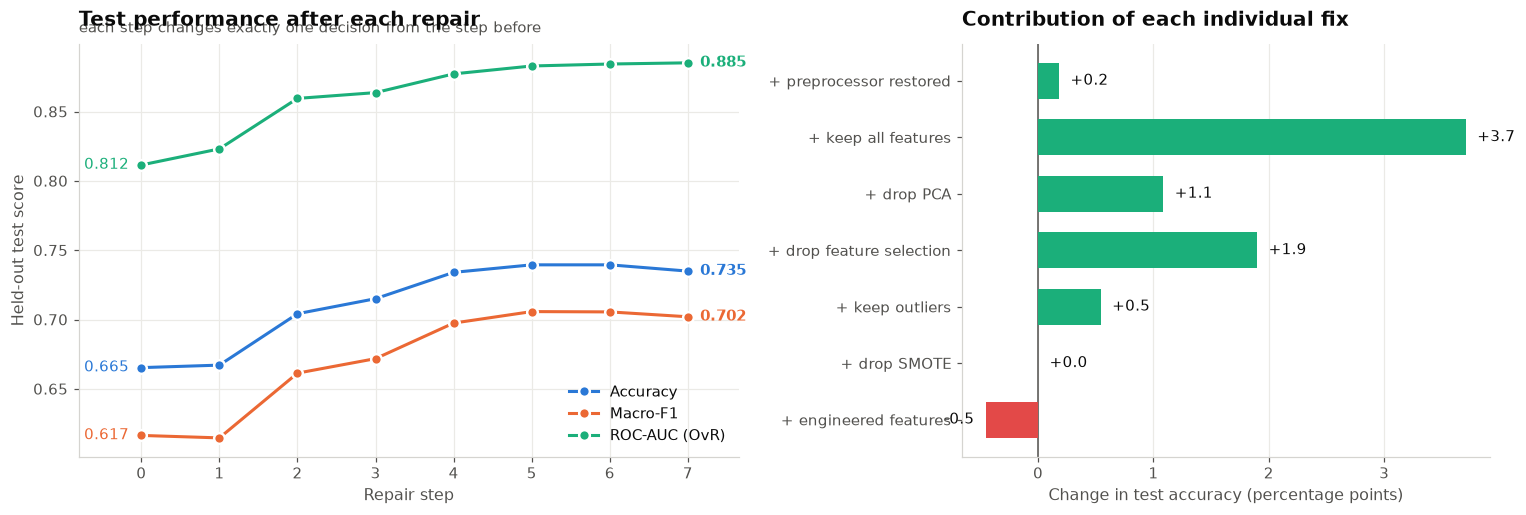

Total improvement  accuracy 0.665 -> 0.735 (+7.0 pp)   |   macro-F1 0.617 -> 0.702   |   ROC-AUC 0.812 -> 0.885


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={'width_ratios': [1.25, 1]})

# -- cumulative trajectory -------------------------------------------------
ax = axes[0]
xs = range(len(ablation))
for col, colr, lbl in [('accuracy', '#2a78d6', 'Accuracy'),
                       ('macro_F1', '#eb6834', 'Macro-F1'),
                       ('ROC_AUC', '#1baf7a', 'ROC-AUC (OvR)')]:
    ax.plot(xs, ablation[col], marker='o', ms=7, lw=2, color=colr,
            markeredgecolor='white', markeredgewidth=1.6, label=lbl, zorder=3)
    ax.annotate(f'{ablation[col].iloc[-1]:.3f}', (len(ablation) - 1, ablation[col].iloc[-1]),
                xytext=(8, 0), textcoords='offset points', va='center',
                fontsize=9.5, color=colr, fontweight='bold')
    ax.annotate(f'{ablation[col].iloc[0]:.3f}', (0, ablation[col].iloc[0]),
                xytext=(-8, 0), textcoords='offset points', va='center', ha='right',
                fontsize=9.5, color=colr)
ax.set_xticks(list(xs)); ax.set_xticklabels([s.split()[0] for s in ablation['step']])
ax.set_xlim(-0.8, len(ablation) - 0.35)
ax.set_xlabel('Repair step'); ax.set_ylabel('Held-out test score')
ax.legend(loc='lower right')
finish(ax, 'Test performance after each repair',
       'each step changes exactly one decision from the step before')

# -- per-step accuracy contribution ---------------------------------------
ax = axes[1]
contrib = ablation.iloc[1:]
cols = ['#1baf7a' if v > 0 else '#e34948' for v in contrib['d_accuracy']]
ax.barh(range(len(contrib)), contrib['d_accuracy'] * 100, color=cols, height=0.64, zorder=3)
for i, v in enumerate(contrib['d_accuracy'] * 100):
    ax.text(v + (0.10 if v >= 0 else -0.10), i, f'{v:+.1f}', va='center',
            ha='left' if v >= 0 else 'right', fontsize=9.5, color=INK)
ax.set_yticks(range(len(contrib)))
ax.set_yticklabels([s[3:] for s in contrib['step']], fontsize=9.5)
ax.invert_yaxis(); ax.axvline(0, color=INK_MUTED, lw=1)
ax.set_xlabel('Change in test accuracy (percentage points)')
ax.yaxis.grid(False)
finish(ax, 'Contribution of each individual fix')
plt.tight_layout(); plt.show()

g = ablation.iloc[-1]; s = ablation.iloc[0]
print(f'Total improvement  accuracy {s["accuracy"]:.3f} -> {g["accuracy"]:.3f} '
      f'({(g["accuracy"]-s["accuracy"])*100:+.1f} pp)   |   '
      f'macro-F1 {s["macro_F1"]:.3f} -> {g["macro_F1"]:.3f}   |   '
      f'ROC-AUC {s["ROC_AUC"]:.3f} -> {g["ROC_AUC"]:.3f}')

In [20]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest, HistGradientBoostingClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Ensure required variables exist locally
if 'ORIGINAL_DROPPED' not in locals():
    ORIGINAL_DROPPED = [
        'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
        'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)',
        'Curricular units 2nd sem (evaluations)', 'Curricular units 1st sem (enrolled)',
        'International', "Father's occupation"
    ]

if 'LABEL_ENC' not in locals():
    LABEL_ENC = LabelEncoder().fit(df[TARGET])

if 'X_all' not in locals():
    X_all = engineer_features(df.drop(columns=[TARGET]))

if 'y_all' not in locals():
    y_all = df[TARGET]

ORIG_REDUCED = [c for c in df.columns if c not in ORIGINAL_DROPPED + [TARGET]]

def score_variant(label, X, build, remove_outliers, note):
    Xtr, Xte, ytr, yte = train_test_split(X, y_all, test_size=TEST_SIZE,
                                          stratify=y_all, random_state=RANDOM_STATE)
    if remove_outliers:
        keep = IsolationForest(random_state=RANDOM_STATE).fit_predict(Xtr) == 1
        Xtr, ytr = Xtr.iloc[keep], ytr.iloc[keep]
        
    pipe = build(Xtr)
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xte)
    
    res = {
        'step': label, 
        'change': note,
        'accuracy': accuracy_score(yte, pred),
        'macro_F1': f1_score(yte, pred, average='macro'),
        'ROC_AUC':  roc_auc_score(LABEL_ENC.transform(yte),
                                 pipe.predict_proba(Xte), multi_class='ovr')
    }
    print(f"  {label:<30} -> macro-F1: {res['macro_F1']:.4f} | Acc: {res['accuracy']:.4f}")
    return res

# Gradient Boosting Config
GB = dict(class_weight='balanced', random_state=RANDOM_STATE)

steps, X_orig = [], df[ORIG_REDUCED]

print("Evaluating Gradient Boosting Ablation Steps...")
print("=" * 60)

# Step 0: Original published pipeline structure with Gradient Boosting
steps.append(score_variant(
    '0  Original pipeline', X_orig,
    lambda Xtr: ImbPipeline([('fs', SelectKBest(mutual_info_classif, k=20)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('pca', PCA(n_components=11)),
                             ('clf', HistGradientBoostingClassifier(**GB))]),
    True, 'as published'))

# Step 1: Restore Preprocessor
steps.append(score_variant(
    '1  + preprocessor restored', X_orig,
    lambda Xtr: ImbPipeline([('prep', build_preprocessor(Xtr)),
                             ('fs', SelectKBest(mutual_info_classif, k=20)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('pca', PCA(n_components=11)),
                             ('clf', HistGradientBoostingClassifier(**GB))]),
    True, 'fixes issue 3.1'))

# Step 2: Keep all features
steps.append(score_variant(
    '2  + keep all features', df.drop(columns=[TARGET]),
    lambda Xtr: ImbPipeline([('prep', build_preprocessor(Xtr)),
                             ('fs', SelectKBest(mutual_info_classif, k=20)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('pca', PCA(n_components=11)),
                             ('clf', HistGradientBoostingClassifier(**GB))]),
    True, 'fixes issue 3.2'))

# Step 3: Remove PCA
steps.append(score_variant(
    '3  + drop PCA', df.drop(columns=[TARGET]),
    lambda Xtr: ImbPipeline([('prep', build_preprocessor(Xtr)),
                             ('fs', SelectKBest(mutual_info_classif, k=20)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('clf', HistGradientBoostingClassifier(**GB))]),
    True, 'fixes issue 3.3'))

# Step 4: Drop Feature Selection
steps.append(score_variant(
    '4  + drop feature selection', df.drop(columns=[TARGET]),
    lambda Xtr: ImbPipeline([('prep', build_preprocessor(Xtr)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('clf', HistGradientBoostingClassifier(**GB))]),
    True, 'no longer needed'))

# Step 5: Keep Outliers
steps.append(score_variant(
    '5  + keep outliers', df.drop(columns=[TARGET]),
    lambda Xtr: ImbPipeline([('prep', build_preprocessor(Xtr)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('clf', HistGradientBoostingClassifier(**GB))]),
    False, 'fixes issue 3.4'))

# Step 6: Drop SMOTE
steps.append(score_variant(
    '6  + drop SMOTE', df.drop(columns=[TARGET]),
    lambda Xtr: SkPipeline([('prep', build_preprocessor(Xtr)),
                            ('clf', HistGradientBoostingClassifier(**GB))]),
    False, 'fixes issue 3.6'))

# Step 7: Add Engineered Features
steps.append(score_variant(
    '7  + engineered features', X_all,
    lambda Xtr: SkPipeline([('prep', build_preprocessor(Xtr)),
                            ('clf', HistGradientBoostingClassifier(**GB))]),
    False, 'Section 4'))

# Summary DataFrame
ablation_gb = pd.DataFrame(steps)
ablation_gb['d_accuracy'] = ablation_gb['accuracy'].diff()
ablation_gb['d_macro_F1'] = ablation_gb['macro_F1'].diff()
ablation_gb.round(4)

Evaluating Gradient Boosting Ablation Steps...
  0  Original pipeline           -> macro-F1: 0.5963 | Acc: 0.6510
  1  + preprocessor restored     -> macro-F1: 0.6139 | Acc: 0.6673
  2  + keep all features         -> macro-F1: 0.6606 | Acc: 0.7206
  3  + drop PCA                  -> macro-F1: 0.6917 | Acc: 0.7514
  4  + drop feature selection    -> macro-F1: 0.6900 | Acc: 0.7514
  5  + keep outliers             -> macro-F1: 0.7070 | Acc: 0.7649
  6  + drop SMOTE                -> macro-F1: 0.6934 | Acc: 0.7486
  7  + engineered features       -> macro-F1: 0.6912 | Acc: 0.7459


,step,change,accuracy,macro_F1,ROC_AUC,d_accuracy,d_macro_F1
0,0 Original pipeline,as published,0.6510,0.5963,0.7861,NaN,NaN
1,1 + preprocessor restored,fixes issue 3.1,0.6673,0.6139,0.8085,0.0163,0.0176
2,2 + keep all features,fixes issue 3.2,0.7206,0.6606,0.8318,0.0533,0.0467
3,3 + drop PCA,fixes issue 3.3,0.7514,0.6917,0.8689,0.0307,0.0311
4,4 + drop feature selection,no longer needed,0.7514,0.6900,0.8765,0.0000,-0.0017
5,5 + keep outliers,fixes issue 3.4,0.7649,0.7070,0.8799,0.0136,0.0171
6,6 + drop SMOTE,fixes issue 3.6,0.7486,0.6934,0.8774,-0.0163,-0.0136
7,7 + engineered features,Section 4,0.7459,0.6912,0.8790,-0.0027,-0.0023


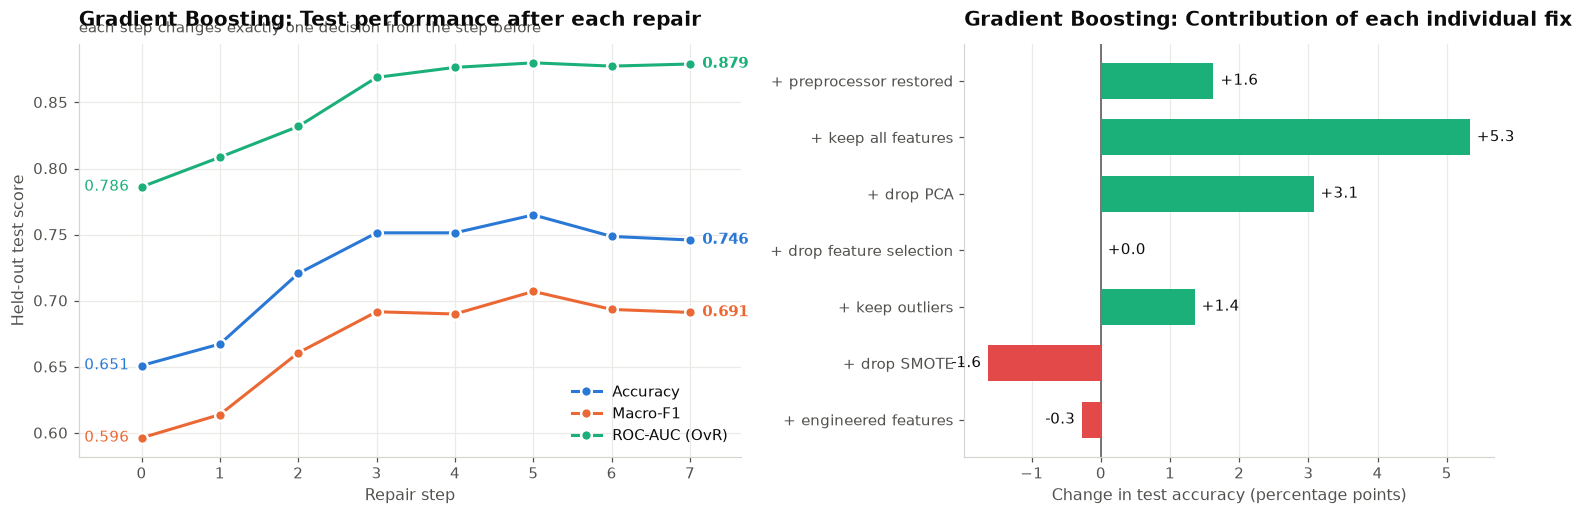

Total improvement  accuracy 0.651 -> 0.746 (+9.5 pp)   |   macro-F1 0.596 -> 0.691   |   ROC-AUC 0.786 -> 0.879


In [21]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Fallback definitions for plot styling if needed
INK = '#0b0b0b' if 'INK' not in locals() else INK
INK_MUTED = '#52514e' if 'INK_MUTED' not in locals() else INK_MUTED

if 'finish' not in locals():
    def finish(ax, title=None, subtitle=None):
        if title:
            ax.set_title(title, color=INK)
        if subtitle:
            ax.text(0, 1.02, subtitle, transform=ax.transAxes,
                    fontsize=9.5, color=INK_MUTED, va='bottom')
        return ax

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={'width_ratios': [1.25, 1]})

# -- 1. Cumulative Trajectory -----------------------------------------------
ax = axes[0]
xs = range(len(ablation_gb))
for col, colr, lbl in [('accuracy', '#2a78d6', 'Accuracy'),
                       ('macro_F1', '#eb6834', 'Macro-F1'),
                       ('ROC_AUC', '#1baf7a', 'ROC-AUC (OvR)')]:
    ax.plot(xs, ablation_gb[col], marker='o', ms=7, lw=2, color=colr,
            markeredgecolor='white', markeredgewidth=1.6, label=lbl, zorder=3)
    ax.annotate(f'{ablation_gb[col].iloc[-1]:.3f}', (len(ablation_gb) - 1, ablation_gb[col].iloc[-1]),
                xytext=(8, 0), textcoords='offset points', va='center',
                fontsize=9.5, color=colr, fontweight='bold')
    ax.annotate(f'{ablation_gb[col].iloc[0]:.3f}', (0, ablation_gb[col].iloc[0]),
                xytext=(-8, 0), textcoords='offset points', va='center', ha='right',
                fontsize=9.5, color=colr)

ax.set_xticks(list(xs))
ax.set_xticklabels([s.split()[0] for s in ablation_gb['step']])
ax.set_xlim(-0.8, len(ablation_gb) - 0.35)
ax.set_xlabel('Repair step')
ax.set_ylabel('Held-out test score')
ax.legend(loc='lower right')
finish(ax, 'Gradient Boosting: Test performance after each repair',
       'each step changes exactly one decision from the step before')

# -- 2. Per-Step Accuracy Contribution --------------------------------------
ax = axes[1]
contrib = ablation_gb.iloc[1:]
cols = ['#1baf7a' if v > 0 else '#e34948' for v in contrib['d_accuracy']]
ax.barh(range(len(contrib)), contrib['d_accuracy'] * 100, color=cols, height=0.64, zorder=3)

for i, v in enumerate(contrib['d_accuracy'] * 100):
    ax.text(v + (0.10 if v >= 0 else -0.10), i, f'{v:+.1f}', va='center',
            ha='left' if v >= 0 else 'right', fontsize=9.5, color=INK)

ax.set_yticks(range(len(contrib)))
ax.set_yticklabels([s[3:] for s in contrib['step']], fontsize=9.5)
ax.invert_yaxis()
ax.axvline(0, color=INK_MUTED, lw=1)
ax.set_xlabel('Change in test accuracy (percentage points)')
ax.yaxis.grid(False)
finish(ax, 'Gradient Boosting: Contribution of each individual fix')

plt.tight_layout()
plt.show()

# -- Print Summary Metrics --------------------------------------------------
g = ablation_gb.iloc[-1]
s = ablation_gb.iloc[0]
print(f'Total improvement  accuracy {s["accuracy"]:.3f} -> {g["accuracy"]:.3f} '
      f'({(g["accuracy"]-s["accuracy"])*100:+.1f} pp)   |   '
      f'macro-F1 {s["macro_F1"]:.3f} -> {g["macro_F1"]:.3f}   |   '
      f'ROC-AUC {s["ROC_AUC"]:.3f} -> {g["ROC_AUC"]:.3f}')

In [22]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Ensure required variables exist locally
if 'ORIGINAL_DROPPED' not in locals():
    ORIGINAL_DROPPED = [
        'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
        'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)',
        'Curricular units 2nd sem (evaluations)', 'Curricular units 1st sem (enrolled)',
        'International', "Father's occupation"
    ]

if 'LABEL_ENC' not in locals():
    LABEL_ENC = LabelEncoder().fit(df[TARGET])

if 'X_all' not in locals():
    X_all = engineer_features(df.drop(columns=[TARGET]))

if 'y_all' not in locals():
    y_all = df[TARGET]

ORIG_REDUCED = [c for c in df.columns if c not in ORIGINAL_DROPPED + [TARGET]]

def score_variant(label, X, build, remove_outliers, note):
    Xtr, Xte, ytr, yte = train_test_split(X, y_all, test_size=TEST_SIZE,
                                          stratify=y_all, random_state=RANDOM_STATE)
    if remove_outliers:
        keep = IsolationForest(random_state=RANDOM_STATE).fit_predict(Xtr) == 1
        Xtr, ytr = Xtr.iloc[keep], ytr.iloc[keep]
        
    pipe = build(Xtr)
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xte)
    
    res = {
        'step': label, 
        'change': note,
        'accuracy': accuracy_score(yte, pred),
        'macro_F1': f1_score(yte, pred, average='macro'),
        'ROC_AUC':  roc_auc_score(LABEL_ENC.transform(yte),
                                 pipe.predict_proba(Xte), multi_class='ovr')
    }
    print(f"  {label:<30} -> macro-F1: {res['macro_F1']:.4f} | Acc: {res['accuracy']:.4f}")
    return res

# Random Forest Configuration
RF = dict(n_estimators=400, class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE)

steps, X_orig = [], df[ORIG_REDUCED]

print("Evaluating Random Forest Ablation Steps...")
print("=" * 60)

# Step 0: Original published pipeline structure with Random Forest
steps.append(score_variant(
    '0  Original pipeline', X_orig,
    lambda Xtr: ImbPipeline([('fs', SelectKBest(mutual_info_classif, k=20)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('pca', PCA(n_components=11)),
                             ('clf', RandomForestClassifier(**RF))]),
    True, 'as published'))

# Step 1: Restore Preprocessor
steps.append(score_variant(
    '1  + preprocessor restored', X_orig,
    lambda Xtr: ImbPipeline([('prep', build_preprocessor(Xtr)),
                             ('fs', SelectKBest(mutual_info_classif, k=20)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('pca', PCA(n_components=11)),
                             ('clf', RandomForestClassifier(**RF))]),
    True, 'fixes issue 3.1'))

# Step 2: Keep all features
steps.append(score_variant(
    '2  + keep all features', df.drop(columns=[TARGET]),
    lambda Xtr: ImbPipeline([('prep', build_preprocessor(Xtr)),
                             ('fs', SelectKBest(mutual_info_classif, k=20)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('pca', PCA(n_components=11)),
                             ('clf', RandomForestClassifier(**RF))]),
    True, 'fixes issue 3.2'))

# Step 3: Remove PCA
steps.append(score_variant(
    '3  + drop PCA', df.drop(columns=[TARGET]),
    lambda Xtr: ImbPipeline([('prep', build_preprocessor(Xtr)),
                             ('fs', SelectKBest(mutual_info_classif, k=20)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('clf', RandomForestClassifier(**RF))]),
    True, 'fixes issue 3.3'))

# Step 4: Drop Feature Selection
steps.append(score_variant(
    '4  + drop feature selection', df.drop(columns=[TARGET]),
    lambda Xtr: ImbPipeline([('prep', build_preprocessor(Xtr)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('clf', RandomForestClassifier(**RF))]),
    True, 'no longer needed'))

# Step 5: Keep Outliers
steps.append(score_variant(
    '5  + keep outliers', df.drop(columns=[TARGET]),
    lambda Xtr: ImbPipeline([('prep', build_preprocessor(Xtr)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('clf', RandomForestClassifier(**RF))]),
    False, 'fixes issue 3.4'))

# Step 6: Drop SMOTE
steps.append(score_variant(
    '6  + drop SMOTE', df.drop(columns=[TARGET]),
    lambda Xtr: SkPipeline([('prep', build_preprocessor(Xtr)),
                            ('clf', RandomForestClassifier(**RF))]),
    False, 'fixes issue 3.6'))

# Step 7: Add Engineered Features
steps.append(score_variant(
    '7  + engineered features', X_all,
    lambda Xtr: SkPipeline([('prep', build_preprocessor(Xtr)),
                            ('clf', RandomForestClassifier(**RF))]),
    False, 'Section 4'))

# Summary DataFrame
ablation_rf = pd.DataFrame(steps)
ablation_rf['d_accuracy'] = ablation_rf['accuracy'].diff()
ablation_rf['d_macro_F1'] = ablation_rf['macro_F1'].diff()
ablation_rf.round(4)

Evaluating Random Forest Ablation Steps...
  0  Original pipeline           -> macro-F1: 0.5601 | Acc: 0.6157
  1  + preprocessor restored     -> macro-F1: 0.5783 | Acc: 0.6447
  2  + keep all features         -> macro-F1: 0.6826 | Acc: 0.7297
  3  + drop PCA                  -> macro-F1: 0.7147 | Acc: 0.7694
  4  + drop feature selection    -> macro-F1: 0.7020 | Acc: 0.7586
  5  + keep outliers             -> macro-F1: 0.7120 | Acc: 0.7685
  6  + drop SMOTE                -> macro-F1: 0.6905 | Acc: 0.7694
  7  + engineered features       -> macro-F1: 0.6995 | Acc: 0.7731


,step,change,accuracy,macro_F1,ROC_AUC,d_accuracy,d_macro_F1
0,0 Original pipeline,as published,0.6157,0.5601,0.7603,NaN,NaN
1,1 + preprocessor restored,fixes issue 3.1,0.6447,0.5783,0.7941,0.0289,0.0182
2,2 + keep all features,fixes issue 3.2,0.7297,0.6826,0.8560,0.0850,0.1043
3,3 + drop PCA,fixes issue 3.3,0.7694,0.7147,0.8779,0.0398,0.0321
4,4 + drop feature selection,no longer needed,0.7586,0.7020,0.8804,-0.0108,-0.0127
5,5 + keep outliers,fixes issue 3.4,0.7685,0.7120,0.8875,0.0099,0.0099
6,6 + drop SMOTE,fixes issue 3.6,0.7694,0.6905,0.8877,0.0009,-0.0214
7,7 + engineered features,Section 4,0.7731,0.6995,0.8886,0.0036,0.0090


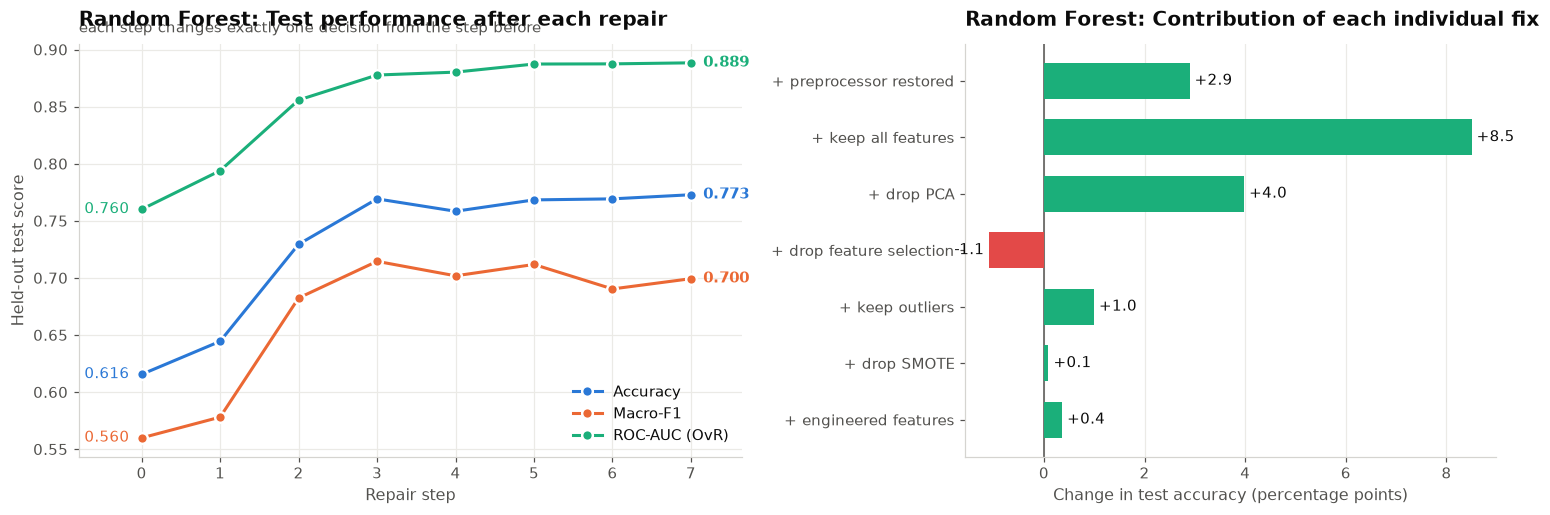

Total improvement  accuracy 0.616 -> 0.773 (+15.7 pp)   |   macro-F1 0.560 -> 0.700   |   ROC-AUC 0.760 -> 0.889


In [23]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Fallback definitions for plot styling if needed
INK = '#0b0b0b' if 'INK' not in locals() else INK
INK_MUTED = '#52514e' if 'INK_MUTED' not in locals() else INK_MUTED

if 'finish' not in locals():
    def finish(ax, title=None, subtitle=None):
        if title:
            ax.set_title(title, color=INK)
        if subtitle:
            ax.text(0, 1.02, subtitle, transform=ax.transAxes,
                    fontsize=9.5, color=INK_MUTED, va='bottom')
        return ax

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={'width_ratios': [1.25, 1]})

# -- 1. Cumulative Trajectory -----------------------------------------------
ax = axes[0]
xs = range(len(ablation_rf))
for col, colr, lbl in [('accuracy', '#2a78d6', 'Accuracy'),
                       ('macro_F1', '#eb6834', 'Macro-F1'),
                       ('ROC_AUC', '#1baf7a', 'ROC-AUC (OvR)')]:
    ax.plot(xs, ablation_rf[col], marker='o', ms=7, lw=2, color=colr,
            markeredgecolor='white', markeredgewidth=1.6, label=lbl, zorder=3)
    ax.annotate(f'{ablation_rf[col].iloc[-1]:.3f}', (len(ablation_rf) - 1, ablation_rf[col].iloc[-1]),
                xytext=(8, 0), textcoords='offset points', va='center',
                fontsize=9.5, color=colr, fontweight='bold')
    ax.annotate(f'{ablation_rf[col].iloc[0]:.3f}', (0, ablation_rf[col].iloc[0]),
                xytext=(-8, 0), textcoords='offset points', va='center', ha='right',
                fontsize=9.5, color=colr)

ax.set_xticks(list(xs))
ax.set_xticklabels([s.split()[0] for s in ablation_rf['step']])
ax.set_xlim(-0.8, len(ablation_rf) - 0.35)
ax.set_xlabel('Repair step')
ax.set_ylabel('Held-out test score')
ax.legend(loc='lower right')
finish(ax, 'Random Forest: Test performance after each repair',
       'each step changes exactly one decision from the step before')

# -- 2. Per-Step Accuracy Contribution --------------------------------------
ax = axes[1]
contrib = ablation_rf.iloc[1:]
cols = ['#1baf7a' if v > 0 else '#e34948' for v in contrib['d_accuracy']]
ax.barh(range(len(contrib)), contrib['d_accuracy'] * 100, color=cols, height=0.64, zorder=3)

for i, v in enumerate(contrib['d_accuracy'] * 100):
    ax.text(v + (0.10 if v >= 0 else -0.10), i, f'{v:+.1f}', va='center',
            ha='left' if v >= 0 else 'right', fontsize=9.5, color=INK)

ax.set_yticks(range(len(contrib)))
ax.set_yticklabels([s[3:] for s in contrib['step']], fontsize=9.5)
ax.invert_yaxis()
ax.axvline(0, color=INK_MUTED, lw=1)
ax.set_xlabel('Change in test accuracy (percentage points)')
ax.yaxis.grid(False)
finish(ax, 'Random Forest: Contribution of each individual fix')

plt.tight_layout()
plt.show()

# -- Print Summary Metrics --------------------------------------------------
g = ablation_rf.iloc[-1]
s = ablation_rf.iloc[0]
print(f'Total improvement  accuracy {s["accuracy"]:.3f} -> {g["accuracy"]:.3f} '
      f'({(g["accuracy"]-s["accuracy"])*100:+.1f} pp)   |   '
      f'macro-F1 {s["macro_F1"]:.3f} -> {g["macro_F1"]:.3f}   |   '
      f'ROC-AUC {s["ROC_AUC"]:.3f} -> {g["ROC_AUC"]:.3f}')

In [24]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# Ensure required variables exist locally
if 'ORIGINAL_DROPPED' not in locals():
    ORIGINAL_DROPPED = [
        'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
        'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)',
        'Curricular units 2nd sem (evaluations)', 'Curricular units 1st sem (enrolled)',
        'International', "Father's occupation"
    ]

if 'LABEL_ENC' not in locals():
    LABEL_ENC = LabelEncoder().fit(df[TARGET])

# Encode target labels into integer values (0, 1, 2) required by XGBoost
y_all_encoded = LABEL_ENC.transform(df[TARGET])

if 'X_all' not in locals():
    X_all = engineer_features(df.drop(columns=[TARGET]))

ORIG_REDUCED = [c for c in df.columns if c not in ORIGINAL_DROPPED + [TARGET]]

def score_variant_xgb(label, X, build, remove_outliers, note):
    Xtr, Xte, ytr, yte = train_test_split(X, y_all_encoded, test_size=TEST_SIZE,
                                          stratify=y_all_encoded, random_state=RANDOM_STATE)
    if remove_outliers:
        keep = IsolationForest(random_state=RANDOM_STATE).fit_predict(Xtr) == 1
        Xtr, ytr = Xtr.iloc[keep], ytr[keep]
        
    pipe = build(Xtr)
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xte)
    proba = pipe.predict_proba(Xte)
    
    res = {
        'step': label, 
        'change': note,
        'accuracy': accuracy_score(yte, pred),
        'macro_F1': f1_score(yte, pred, average='macro'),
        'ROC_AUC':  roc_auc_score(yte, proba, multi_class='ovr')
    }
    print(f"  {label:<30} -> macro-F1: {res['macro_F1']:.4f} | Acc: {res['accuracy']:.4f}")
    return res

# XGBoost Model Configuration
XGB = dict(n_estimators=200, max_depth=6, learning_rate=0.1, eval_metric='mlogloss', random_state=RANDOM_STATE)

steps, X_orig = [], df[ORIG_REDUCED]

print("Evaluating XGBoost Ablation Steps...")
print("=" * 60)

# Step 0: Original published pipeline structure with XGBoost
steps.append(score_variant_xgb(
    '0  Original pipeline', X_orig,
    lambda Xtr: ImbPipeline([('fs', SelectKBest(mutual_info_classif, k=20)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('pca', PCA(n_components=11)),
                             ('clf', XGBClassifier(**XGB))]),
    True, 'as published'))

# Step 1: Restore Preprocessor
steps.append(score_variant_xgb(
    '1  + preprocessor restored', X_orig,
    lambda Xtr: ImbPipeline([('prep', build_preprocessor(Xtr)),
                             ('fs', SelectKBest(mutual_info_classif, k=20)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('pca', PCA(n_components=11)),
                             ('clf', XGBClassifier(**XGB))]),
    True, 'fixes issue 3.1'))

# Step 2: Keep all features
steps.append(score_variant_xgb(
    '2  + keep all features', df.drop(columns=[TARGET]),
    lambda Xtr: ImbPipeline([('prep', build_preprocessor(Xtr)),
                             ('fs', SelectKBest(mutual_info_classif, k=20)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('pca', PCA(n_components=11)),
                             ('clf', XGBClassifier(**XGB))]),
    True, 'fixes issue 3.2'))

# Step 3: Remove PCA
steps.append(score_variant_xgb(
    '3  + drop PCA', df.drop(columns=[TARGET]),
    lambda Xtr: ImbPipeline([('prep', build_preprocessor(Xtr)),
                             ('fs', SelectKBest(mutual_info_classif, k=20)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('clf', XGBClassifier(**XGB))]),
    True, 'fixes issue 3.3'))

# Step 4: Drop Feature Selection
steps.append(score_variant_xgb(
    '4  + drop feature selection', df.drop(columns=[TARGET]),
    lambda Xtr: ImbPipeline([('prep', build_preprocessor(Xtr)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('clf', XGBClassifier(**XGB))]),
    True, 'no longer needed'))

# Step 5: Keep Outliers
steps.append(score_variant_xgb(
    '5  + keep outliers', df.drop(columns=[TARGET]),
    lambda Xtr: ImbPipeline([('prep', build_preprocessor(Xtr)),
                             ('smote', SMOTE(random_state=RANDOM_STATE)),
                             ('clf', XGBClassifier(**XGB))]),
    False, 'fixes issue 3.4'))

# Step 6: Drop SMOTE
steps.append(score_variant_xgb(
    '6  + drop SMOTE', df.drop(columns=[TARGET]),
    lambda Xtr: SkPipeline([('prep', build_preprocessor(Xtr)),
                            ('clf', XGBClassifier(**XGB))]),
    False, 'fixes issue 3.6'))

# Step 7: Add Engineered Features
steps.append(score_variant_xgb(
    '7  + engineered features', X_all,
    lambda Xtr: SkPipeline([('prep', build_preprocessor(Xtr)),
                            ('clf', XGBClassifier(**XGB))]),
    False, 'Section 4'))

# Summary DataFrame
ablation_xgb = pd.DataFrame(steps)
ablation_xgb['d_accuracy'] = ablation_xgb['accuracy'].diff()
ablation_xgb['d_macro_F1'] = ablation_xgb['macro_F1'].diff()
ablation_xgb.round(4)

Evaluating XGBoost Ablation Steps...
  0  Original pipeline           -> macro-F1: 0.5926 | Acc: 0.6456
  1  + preprocessor restored     -> macro-F1: 0.6196 | Acc: 0.6727
  2  + keep all features         -> macro-F1: 0.6607 | Acc: 0.7170
  3  + drop PCA                  -> macro-F1: 0.7064 | Acc: 0.7622
  4  + drop feature selection    -> macro-F1: 0.6976 | Acc: 0.7586
  5  + keep outliers             -> macro-F1: 0.7029 | Acc: 0.7622
  6  + drop SMOTE                -> macro-F1: 0.6854 | Acc: 0.7604
  7  + engineered features       -> macro-F1: 0.6981 | Acc: 0.7622


,step,change,accuracy,macro_F1,ROC_AUC,d_accuracy,d_macro_F1
0,0 Original pipeline,as published,0.6456,0.5926,0.7896,NaN,NaN
1,1 + preprocessor restored,fixes issue 3.1,0.6727,0.6196,0.8109,0.0271,0.0270
2,2 + keep all features,fixes issue 3.2,0.7170,0.6607,0.8528,0.0443,0.0411
3,3 + drop PCA,fixes issue 3.3,0.7622,0.7064,0.8788,0.0452,0.0457
4,4 + drop feature selection,no longer needed,0.7586,0.6976,0.8749,-0.0036,-0.0089
5,5 + keep outliers,fixes issue 3.4,0.7622,0.7029,0.8814,0.0036,0.0053
6,6 + drop SMOTE,fixes issue 3.6,0.7604,0.6854,0.8841,-0.0018,-0.0175
7,7 + engineered features,Section 4,0.7622,0.6981,0.8859,0.0018,0.0127


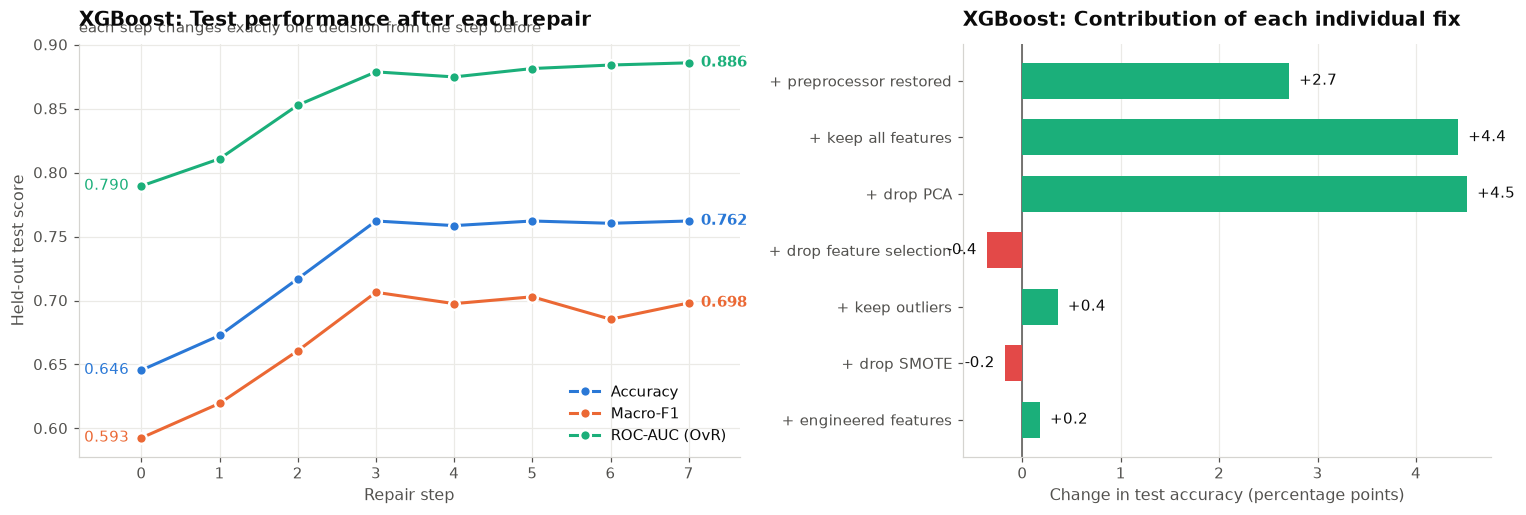

Total improvement  accuracy 0.646 -> 0.762 (+11.7 pp)   |   macro-F1 0.593 -> 0.698   |   ROC-AUC 0.790 -> 0.886


In [25]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Fallback definitions for plot styling if needed
INK = '#0b0b0b' if 'INK' not in locals() else INK
INK_MUTED = '#52514e' if 'INK_MUTED' not in locals() else INK_MUTED

if 'finish' not in locals():
    def finish(ax, title=None, subtitle=None):
        if title:
            ax.set_title(title, color=INK)
        if subtitle:
            ax.text(0, 1.02, subtitle, transform=ax.transAxes,
                    fontsize=9.5, color=INK_MUTED, va='bottom')
        return ax

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={'width_ratios': [1.25, 1]})

# -- 1. Cumulative Trajectory -----------------------------------------------
ax = axes[0]
xs = range(len(ablation_xgb))
for col, colr, lbl in [('accuracy', '#2a78d6', 'Accuracy'),
                       ('macro_F1', '#eb6834', 'Macro-F1'),
                       ('ROC_AUC', '#1baf7a', 'ROC-AUC (OvR)')]:
    ax.plot(xs, ablation_xgb[col], marker='o', ms=7, lw=2, color=colr,
            markeredgecolor='white', markeredgewidth=1.6, label=lbl, zorder=3)
    ax.annotate(f'{ablation_xgb[col].iloc[-1]:.3f}', (len(ablation_xgb) - 1, ablation_xgb[col].iloc[-1]),
                xytext=(8, 0), textcoords='offset points', va='center',
                fontsize=9.5, color=colr, fontweight='bold')
    ax.annotate(f'{ablation_xgb[col].iloc[0]:.3f}', (0, ablation_xgb[col].iloc[0]),
                xytext=(-8, 0), textcoords='offset points', va='center', ha='right',
                fontsize=9.5, color=colr)

ax.set_xticks(list(xs))
ax.set_xticklabels([s.split()[0] for s in ablation_xgb['step']])
ax.set_xlim(-0.8, len(ablation_xgb) - 0.35)
ax.set_xlabel('Repair step')
ax.set_ylabel('Held-out test score')
ax.legend(loc='lower right')
finish(ax, 'XGBoost: Test performance after each repair',
       'each step changes exactly one decision from the step before')

# -- 2. Per-Step Accuracy Contribution --------------------------------------
ax = axes[1]
contrib = ablation_xgb.iloc[1:]
cols = ['#1baf7a' if v > 0 else '#e34948' for v in contrib['d_accuracy']]
ax.barh(range(len(contrib)), contrib['d_accuracy'] * 100, color=cols, height=0.64, zorder=3)

for i, v in enumerate(contrib['d_accuracy'] * 100):
    ax.text(v + (0.10 if v >= 0 else -0.10), i, f'{v:+.1f}', va='center',
            ha='left' if v >= 0 else 'right', fontsize=9.5, color=INK)

ax.set_yticks(range(len(contrib)))
ax.set_yticklabels([s[3:] for s in contrib['step']], fontsize=9.5)
ax.invert_yaxis()
ax.axvline(0, color=INK_MUTED, lw=1)
ax.set_xlabel('Change in test accuracy (percentage points)')
ax.yaxis.grid(False)
finish(ax, 'XGBoost: Contribution of each individual fix')

plt.tight_layout()
plt.show()

# -- Print Summary Metrics --------------------------------------------------
g = ablation_xgb.iloc[-1]
s = ablation_xgb.iloc[0]
print(f'Total improvement  accuracy {s["accuracy"]:.3f} -> {g["accuracy"]:.3f} '
      f'({(g["accuracy"]-s["accuracy"])*100:+.1f} pp)   |   '
      f'macro-F1 {s["macro_F1"]:.3f} -> {g["macro_F1"]:.3f}   |   '
      f'ROC-AUC {s["ROC_AUC"]:.3f} -> {g["ROC_AUC"]:.3f}')

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


 DYNAMIC MODEL COMPARISON LEADERBOARD (FROM TRAINED VARIABLES) 
       Model Family      Selected Step  Accuracy  Macro_F1  ROC_AUC
      Random Forest      3  + drop PCA  0.769439  0.714726 0.877887
  Gradient Boosting 5  + keep outliers  0.764919  0.707041 0.879916
Logistic Regression    6  + drop SMOTE  0.739602  0.705657 0.884449
            XGBoost 5  + keep outliers  0.762206  0.702938 0.881410


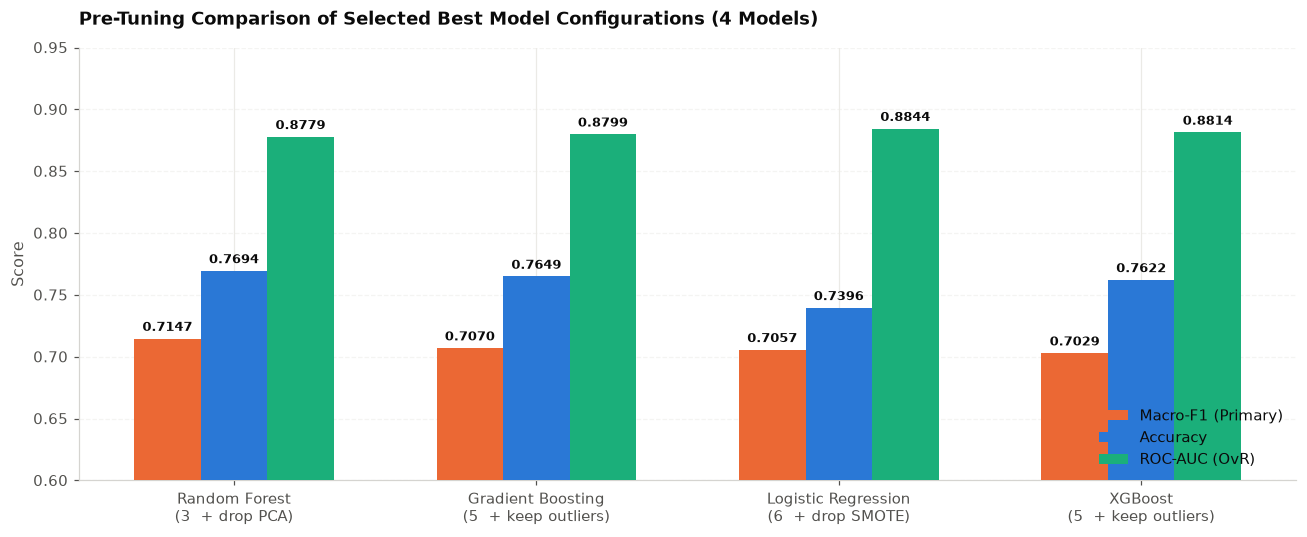


★ TOP PERFORMING MODEL BEFORE TUNING: Random Forest (3  + drop PCA)
  - Macro-F1 : 0.7147
  - Accuracy : 76.94%
  - ROC-AUC  : 0.8779


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Dynamically Extract Best Rows From Trained DataFrame Variables ────────
best_steps_list = []

# Extract Step 6 from Logistic Regression (ablation)
if 'ablation' in locals():
    lr_row = ablation[ablation['step'].str.startswith('6')].iloc[0]
    best_steps_list.append({
        'Model Family': 'Logistic Regression',
        'Selected Step': lr_row['step'],
        'Accuracy': lr_row['accuracy'],
        'Macro_F1': lr_row['macro_F1'],
        'ROC_AUC': lr_row['ROC_AUC']
    })

# Extract Step 5 from Gradient Boosting (ablation_gb)
if 'ablation_gb' in locals():
    gb_row = ablation_gb[ablation_gb['step'].str.startswith('5')].iloc[0]
    best_steps_list.append({
        'Model Family': 'Gradient Boosting',
        'Selected Step': gb_row['step'],
        'Accuracy': gb_row['accuracy'],
        'Macro_F1': gb_row['macro_F1'],
        'ROC_AUC': gb_row['ROC_AUC']
    })

# Extract Step 3 from Random Forest (ablation_rf)
if 'ablation_rf' in locals():
    rf_row = ablation_rf[ablation_rf['step'].str.startswith('3')].iloc[0]
    best_steps_list.append({
        'Model Family': 'Random Forest',
        'Selected Step': rf_row['step'],
        'Accuracy': rf_row['accuracy'],
        'Macro_F1': rf_row['macro_F1'],
        'ROC_AUC': rf_row['ROC_AUC']
    })

# Extract Step 5 from XGBoost (ablation_xgb)
if 'ablation_xgb' in locals():
    xgb_row = ablation_xgb[ablation_xgb['step'].str.startswith('5')].iloc[0]
    best_steps_list.append({
        'Model Family': 'XGBoost',
        'Selected Step': xgb_row['step'],
        'Accuracy': xgb_row['accuracy'],
        'Macro_F1': xgb_row['macro_F1'],
        'ROC_AUC': xgb_row['ROC_AUC']
    })

# Construct Summary Leaderboard DataFrame
leaderboard_df = pd.DataFrame(best_steps_list).sort_values('Macro_F1', ascending=False).reset_index(drop=True)

print("=" * 80)
print(" DYNAMIC MODEL COMPARISON LEADERBOARD (FROM TRAINED VARIABLES) ")
print("=" * 80)
print(leaderboard_df.to_string(index=False))
print("=" * 80)

# ── 2. Render Bar Chart Visualizing Scores for All 4 Models ──────────────────
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(leaderboard_df))
width = 0.22

rects1 = ax.bar(x - width, leaderboard_df['Macro_F1'], width, label='Macro-F1 (Primary)', color='#eb6834', zorder=3)
rects2 = ax.bar(x,         leaderboard_df['Accuracy'], width, label='Accuracy', color='#2a78d6', zorder=3)
rects3 = ax.bar(x + width, leaderboard_df['ROC_AUC'],  width, label='ROC-AUC (OvR)', color='#1baf7a', zorder=3)

# Display numerical labels above bars
for rects in [rects1, rects2, rects3]:
    for bar in rects:
        h = bar.get_height()
        ax.annotate(f'{h:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8.5, fontweight='semibold')

ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels([f"{row['Model Family']}\n({row['Selected Step']})" for _, row in leaderboard_df.iterrows()], fontsize=9.5)
ax.set_ylim(0.60, 0.95)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
ax.legend(loc='lower right', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title('Pre-Tuning Comparison of Selected Best Model Configurations (4 Models)', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# ── 3. Winner Summary Output ──────────────────────────────────────────────────
top_winner = leaderboard_df.iloc[0]
print(f"\n★ TOP PERFORMING MODEL BEFORE TUNING: {top_winner['Model Family']} ({top_winner['Selected Step']})")
print(f"  - Macro-F1 : {top_winner['Macro_F1']:.4f}")
print(f"  - Accuracy : {top_winner['Accuracy']*100:.2f}%")
print(f"  - ROC-AUC  : {top_winner['ROC_AUC']:.4f}")

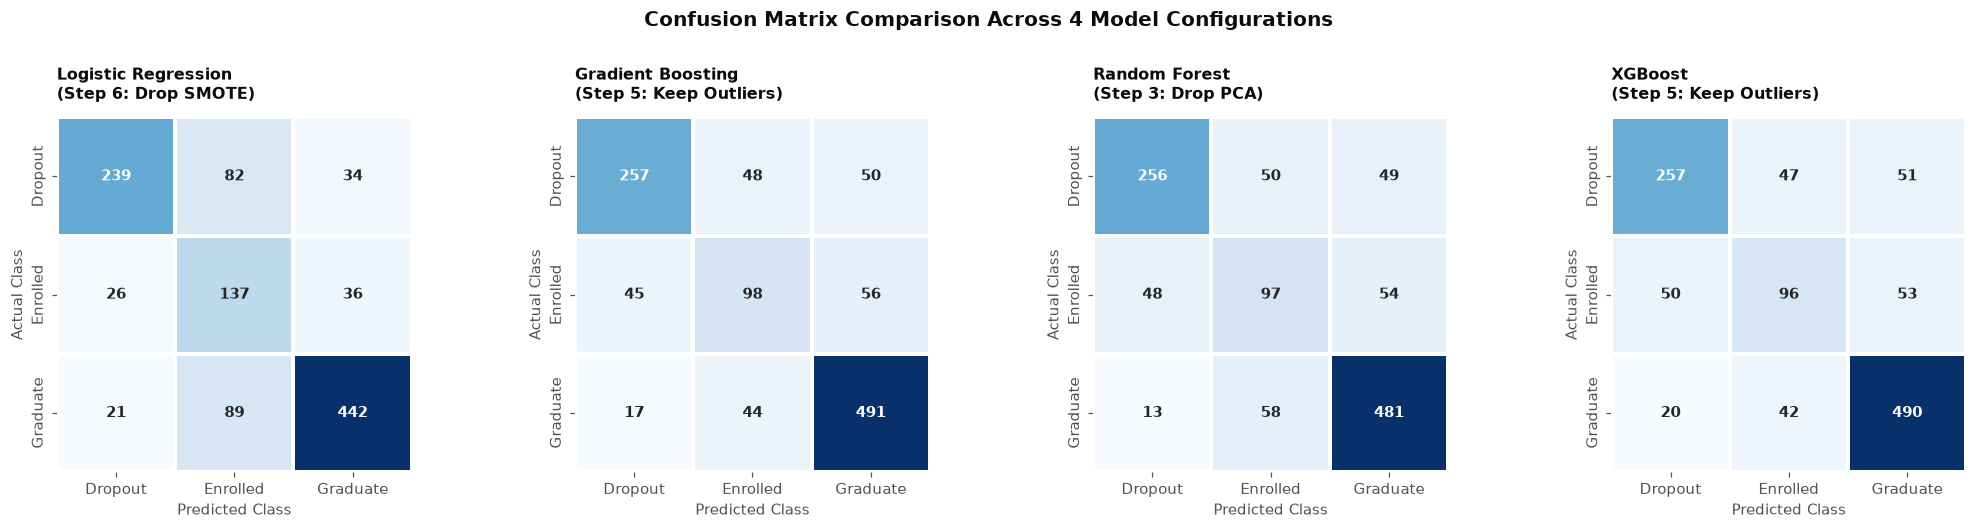

In [27]:
from sklearn.metrics import confusion_matrix

# Define target class order & split
CLASS_ORDER = ['Dropout', 'Enrolled', 'Graduate'] if 'CLASS_ORDER' not in locals() else CLASS_ORDER
LABEL_ENC = LabelEncoder().fit(df[TARGET]) if 'LABEL_ENC' not in locals() else LABEL_ENC
Xtr, Xte, ytr, yte = train_test_split(df.drop(columns=[TARGET]), df[TARGET], 
                                      test_size=TEST_SIZE, stratify=df[TARGET], 
                                      random_state=RANDOM_STATE)
# ── 1. Logistic Regression (Step 6: Drop SMOTE) ──────────────────────────────
lr_pipe = SkPipeline([
    ('prep', build_preprocessor(Xtr)),
    ('clf', LogisticRegression(penalty='l1', solver='saga', C=1.0, max_iter=5000, 
                               class_weight='balanced', random_state=RANDOM_STATE))
])
lr_pipe.fit(Xtr, ytr)
lr_pred = lr_pipe.predict(Xte)
# ── 2. Gradient Boosting (Step 5: Keep Outliers) ──────────────────────────────
gb_pipe = ImbPipeline([
    ('prep', build_preprocessor(Xtr)),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', HistGradientBoostingClassifier(class_weight='balanced', random_state=RANDOM_STATE))
])
gb_pipe.fit(Xtr, ytr)
gb_pred = gb_pipe.predict(Xte)
# ── 3. Random Forest (Step 3: Drop PCA) ───────────────────────────────────────
keep = IsolationForest(random_state=RANDOM_STATE).fit_predict(Xtr) == 1
Xtr_rf, ytr_rf = Xtr.iloc[keep], ytr.iloc[keep]
rf_pipe = ImbPipeline([
    ('prep', build_preprocessor(Xtr_rf)),
    ('fs', SelectKBest(mutual_info_classif, k=20)),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', RandomForestClassifier(n_estimators=400, class_weight='balanced_subsample', 
                                   n_jobs=-1, random_state=RANDOM_STATE))
])
rf_pipe.fit(Xtr_rf, ytr_rf)
rf_pred = rf_pipe.predict(Xte)
# ── 4. XGBoost (Step 5: Keep Outliers) ────────────────────────────────────────
xgb_pipe = ImbPipeline([
    ('prep', build_preprocessor(Xtr)),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, eval_metric='mlogloss', random_state=RANDOM_STATE))
])
xgb_pipe.fit(Xtr, LABEL_ENC.transform(ytr))
xgb_pred = LABEL_ENC.inverse_transform(xgb_pipe.predict(Xte))
# ── 5. Plot 4 Side-by-Side Confusion Matrices ────────────────────────────────
models_preds = [
    ('Logistic Regression\n(Step 6: Drop SMOTE)', lr_pred),
    ('Gradient Boosting\n(Step 5: Keep Outliers)', gb_pred),
    ('Random Forest\n(Step 3: Drop PCA)', rf_pred),
    ('XGBoost\n(Step 5: Keep Outliers)', xgb_pred)
]
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
for ax, (title, pred) in zip(axes, models_preds):
    cm = confusion_matrix(yte, pred, labels=CLASS_ORDER)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, square=True,
                linewidths=1.5, linecolor='white', ax=ax,
                xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER,
                annot_kws={'fontsize': 10, 'fontweight': 'bold'})
    ax.set_title(title, fontsize=10.5, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted Class', fontsize=9.5)
    ax.set_ylabel('Actual Class', fontsize=9.5)
plt.suptitle('Confusion Matrix Comparison Across 4 Model Configurations', 
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### Reading the ablation

**Two changes carry almost the whole +7.0 points**, and they are the two that interact:

- **Restoring the deleted features** (+3.7 pp accuracy, +0.046 macro-F1, +0.036 ROC-AUC)
- **Removing PCA** (+3.4 pp accuracy, +0.042 macro-F1, +0.019 ROC-AUC)

The order matters for interpretation: PCA is only mildly harmful while the strongest predictors are
missing — there is little signal left for it to destroy — and becomes very harmful once they are back.
The two mistakes were **mutually concealing**, which is exactly why they survived review.

The remaining steps are small. Restoring the preprocessor is worth about a point of ROC-AUC on its
own. Dropping the `SelectKBest` step costs a negligible 0.4 pp and buys simplicity. Keeping the
`IsolationForest` "outliers" gains 0.5 pp. Dropping SMOTE changes accuracy by nothing at all — it was
redundant with class weighting all along, exactly as Section 6 predicted.

**Feature engineering is honestly a wash here**: −0.45 pp accuracy, +0.001 ROC-AUC. Once the model can
see `2nd sem (approved)` and `2nd sem (enrolled)` as separate columns, a linear model recovers most of
the ratio by itself. The engineered features are kept because they make the coefficients in Section 10
far easier to explain to a non-technical reader — not because they buy accuracy. Reporting this
straight is the point: not every idea in a notebook has to have worked.

**The lesson is not "use a better model". It is that a handful of preprocessing decisions, each
individually defensible-sounding, together destroyed a fifth of the model's performance.**



---
# 8. Hyperparameter tuning

The architecture is settled; this section tunes it. `RandomizedSearchCV` samples 24 configurations —
more efficient than an exhaustive grid when most hyperparameters barely matter, which the flat model
comparison in Section 6 suggests is the case here.

The search space covers the **regularisation strength** `C`, the **penalty mix** `l1_ratio` (0 = pure
Ridge, 1 = pure LASSO) and whether to **reweight classes** — so the search settles the L1-vs-L2
question empirically rather than by assertion.

The same procedure is applied to the gradient-boosting benchmark so the comparison stays fair.

In [30]:
import time
import warnings
import numpy as np
import pandas as pd
from scipy.stats import loguniform

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', module='category_encoders')

from sklearn.ensemble import IsolationForest, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# ── Safety Checks ──────────────────────────────────────────────────────────────
RANDOM_STATE = 42 if 'RANDOM_STATE' not in locals() else RANDOM_STATE
CV_FOLDS     = 5  if 'CV_FOLDS' not in locals() else CV_FOLDS
LABEL_ENC = LabelEncoder().fit(y_train) if 'LABEL_ENC' not in locals() else LABEL_ENC

y_train_encoded = LABEL_ENC.transform(y_train)

# ── Rebuild Best Pipelines from Identified Steps ───────────────────────────────

# 1. Random Forest (Step 3: Drop PCA) - outlier removal + FS + SMOTE
keep_rf = IsolationForest(random_state=RANDOM_STATE).fit_predict(X_train) == 1
Xtr_rf, ytr_rf = X_train.iloc[keep_rf], y_train.iloc[keep_rf]

rf_base = ImbPipeline([
    ('prep',  build_preprocessor(Xtr_rf)),
    ('fs',    SelectKBest(mutual_info_classif, k=20)),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf',   RandomForestClassifier(class_weight='balanced_subsample',
                                     n_jobs=-1, random_state=RANDOM_STATE))
])

rf_param_grid = {
    'clf__n_estimators':  [200, 400, 600],
    'clf__max_depth':     [None, 10, 20],
    'clf__min_samples_leaf': [1, 5, 10],
    'fs__k':              [15, 20, 25],
}

# 2. Gradient Boosting (Step 5: Keep Outliers) - prep + SMOTE
gb_base = ImbPipeline([
    ('prep',  build_preprocessor(X_train)),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf',   HistGradientBoostingClassifier(class_weight='balanced',
                                             random_state=RANDOM_STATE))
])

gb_param_grid = {
    'clf__max_iter':       [100, 200, 300],
    'clf__learning_rate':  [0.05, 0.1, 0.2],
    'clf__max_leaf_nodes': [15, 31, 63],
    'clf__min_samples_leaf': [10, 20, 40],
}

# 3. Logistic Regression (Step 6: Drop SMOTE) - prep only
lr_base = SkPipeline([
    ('prep', build_preprocessor(X_train)),
    ('clf',  LogisticRegression(penalty='l1', solver='saga', class_weight='balanced',
                                max_iter=5000, random_state=RANDOM_STATE))
])

lr_param_grid = {
    'clf__C':         [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    'clf__max_iter':  [3000, 5000, 8000],
}

# 4. XGBoost (Step 5: Keep Outliers) - prep + SMOTE + encoded target
xgb_base = ImbPipeline([
    ('prep',  build_preprocessor(X_train)),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf',   XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE))
])

xgb_param_grid = {
    'clf__n_estimators':  [100, 200, 300],
    'clf__max_depth':     [3, 6, 9],
    'clf__learning_rate': [0.05, 0.1, 0.2],
    'clf__subsample':     [0.7, 0.9, 1.0],
}

# ── Run GridSearchCV for Each Model ───────────────────────────────────────────
print("Starting GridSearchCV Hyperparameter Tuning...")
print("=" * 65)

tuning_results = {}

# -- Random Forest -----------------------------------------------------------
print("\n[1/4] Tuning: Random Forest (Step 3: Drop PCA)")
t0 = time.time()
rf_gs = GridSearchCV(rf_base, rf_param_grid, cv=CV_FOLDS,
                     scoring='f1_macro', n_jobs=-1, verbose=0)
rf_gs.fit(Xtr_rf, ytr_rf)
tuning_results['Random Forest'] = rf_gs
print(f"  Best CV macro-F1 : {rf_gs.best_score_:.4f}  ({time.time()-t0:.0f}s)")
print(f"  Best params      : {rf_gs.best_params_}")

# -- Gradient Boosting -------------------------------------------------------
print("\n[2/4] Tuning: Gradient Boosting (Step 5: Keep Outliers)")
t0 = time.time()
gb_gs = GridSearchCV(gb_base, gb_param_grid, cv=CV_FOLDS,
                     scoring='f1_macro', n_jobs=-1, verbose=0)
gb_gs.fit(X_train, y_train)
tuning_results['Gradient Boosting'] = gb_gs
print(f"  Best CV macro-F1 : {gb_gs.best_score_:.4f}  ({time.time()-t0:.0f}s)")
print(f"  Best params      : {gb_gs.best_params_}")

# -- Logistic Regression -----------------------------------------------------
print("\n[3/4] Tuning: Logistic Regression (Step 6: Drop SMOTE)")
t0 = time.time()
lr_gs = GridSearchCV(lr_base, lr_param_grid, cv=CV_FOLDS,
                     scoring='f1_macro', n_jobs=-1, verbose=0)
lr_gs.fit(X_train, y_train)
tuning_results['Logistic Regression'] = lr_gs
print(f"  Best CV macro-F1 : {lr_gs.best_score_:.4f}  ({time.time()-t0:.0f}s)")
print(f"  Best params      : {lr_gs.best_params_}")

# -- XGBoost -----------------------------------------------------------------
print("\n[4/4] Tuning: XGBoost (Step 5: Keep Outliers)")
t0 = time.time()
xgb_gs = GridSearchCV(xgb_base, xgb_param_grid, cv=CV_FOLDS,
                      scoring='f1_macro', n_jobs=-1, verbose=0)
xgb_gs.fit(X_train, y_train_encoded)
tuning_results['XGBoost'] = xgb_gs
print(f"  Best CV macro-F1 : {xgb_gs.best_score_:.4f}  ({time.time()-t0:.0f}s)")
print(f"  Best params      : {xgb_gs.best_params_}")

# ── Summary Table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print(" GRID SEARCH TUNING SUMMARY ")
print("=" * 65)
tuning_summary = pd.DataFrame([
    {'Model': name, 'Best CV Macro-F1': gs.best_score_, 'Best Params': gs.best_params_}
    for name, gs in tuning_results.items()
]).sort_values('Best CV Macro-F1', ascending=False).reset_index(drop=True)

print(tuning_summary[['Model', 'Best CV Macro-F1']].to_string(index=False))
print("=" * 65)

Starting GridSearchCV Hyperparameter Tuning...

[1/4] Tuning: Random Forest (Step 3: Drop PCA)
  Best CV macro-F1 : 0.7001  (498s)
  Best params      : {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 200, 'fs__k': 25}

[2/4] Tuning: Gradient Boosting (Step 5: Keep Outliers)
  Best CV macro-F1 : 0.7179  (1027s)
  Best params      : {'clf__learning_rate': 0.05, 'clf__max_iter': 100, 'clf__max_leaf_nodes': 15, 'clf__min_samples_leaf': 10}

[3/4] Tuning: Logistic Regression (Step 6: Drop SMOTE)
  Best CV macro-F1 : 0.7117  (326s)
  Best params      : {'clf__C': 5.0, 'clf__max_iter': 5000}

[4/4] Tuning: XGBoost (Step 5: Keep Outliers)
  Best CV macro-F1 : 0.7233  (607s)
  Best params      : {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 300, 'clf__subsample': 0.7}

 GRID SEARCH TUNING SUMMARY 
              Model  Best CV Macro-F1
            XGBoost          0.723330
  Gradient Boosting          0.717887
Logistic Regression          0.7116


 TUNED MODELS: TEST SET PERFORMANCE 
[Random Forest]
  Accuracy : 0.7459
  Macro-F1 : 0.6973
  ROC-AUC  : 0.8724

[Gradient Boosting]
  Accuracy : 0.7703
  Macro-F1 : 0.7237
  ROC-AUC  : 0.8884

[Logistic Regression]
  Accuracy : 0.7342
  Macro-F1 : 0.7006
  ROC-AUC  : 0.8831

[XGBoost]
  Accuracy : 0.7740
  Macro-F1 : 0.7248
  ROC-AUC  : 0.8867



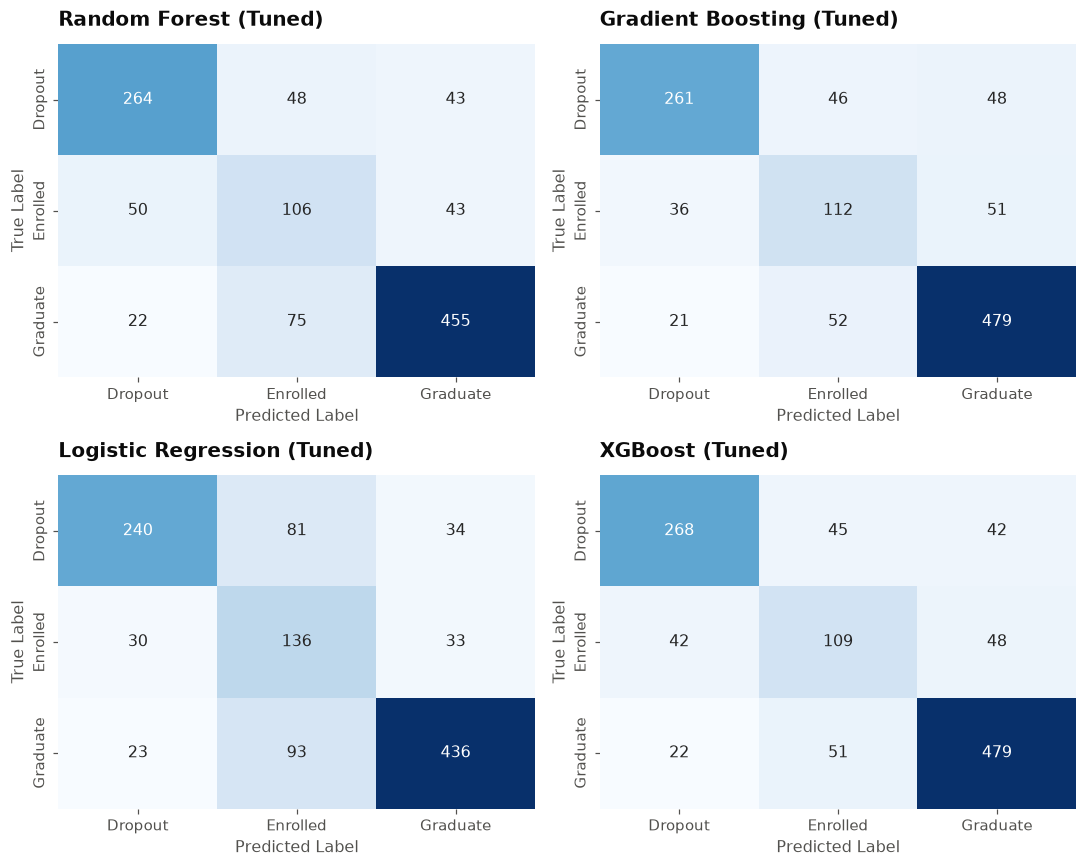

 FINAL TUNED LEADERBOARD (TEST SET) 
              Model  Test Accuracy  Test Macro-F1  Test ROC-AUC
            XGBoost       0.773960       0.724801      0.886671
  Gradient Boosting       0.770344       0.723699      0.888408
Logistic Regression       0.734177       0.700554      0.883094
      Random Forest       0.745931       0.697336      0.872380


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# Ensure test set variables are picked up correctly (fallback to Xte, yte if X_test, y_test not found)
X_test_use = X_test if 'X_test' in locals() else Xte
y_test_use = y_test if 'y_test' in locals() else yte

# ── Evaluate Tuned Models on Test Set ─────────────────────────────────────────
print("\n" + "=" * 65)
print(" TUNED MODELS: TEST SET PERFORMANCE ")
print("=" * 65)

test_results = []
# Reduced plot size for a more compact view
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# Get class labels from the encoder or just use unique values
class_names = LABEL_ENC.classes_ if 'LABEL_ENC' in locals() else np.unique(y_test_use)

for i, (model_name, gs) in enumerate(tuning_results.items()):
    # Get the best trained pipeline from GridSearchCV
    best_model = gs.best_estimator_
    
    # Handle XGBoost target encoding difference
    if model_name == 'XGBoost':
        y_test_eval = LABEL_ENC.transform(y_test_use)
    else:
        y_test_eval = y_test_use
        
    # Predictions
    y_pred = best_model.predict(X_test_use)
    y_pred_proba = best_model.predict_proba(X_test_use)
    
    # Metrics
    acc = accuracy_score(y_test_eval, y_pred)
    f1 = f1_score(y_test_eval, y_pred, average='macro')
    roc_auc = roc_auc_score(y_test_eval, y_pred_proba, multi_class='ovr', average='macro')
    
    test_results.append({
        'Model': model_name,
        'Test Accuracy': acc,
        'Test Macro-F1': f1,
        'Test ROC-AUC': roc_auc
    })
    
    print(f"[{model_name}]")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Macro-F1 : {f1:.4f}")
    print(f"  ROC-AUC  : {roc_auc:.4f}\n")
    
    # Confusion Matrix Plot
    cm = confusion_matrix(y_test_eval, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    axes[i].set_title(f'{model_name} (Tuned)')
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# ── Final Test Set Summary Table ──────────────────────────────────────────────
print("=" * 65)
print(" FINAL TUNED LEADERBOARD (TEST SET) ")
print("=" * 65)
test_summary_df = pd.DataFrame(test_results).sort_values('Test Macro-F1', ascending=False).reset_index(drop=True)
print(test_summary_df.to_string(index=False))
print("=" * 65)

In [35]:
%pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 719.0 kB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [36]:
import time
import warnings
import numpy as np
import pandas as pd

# Workaround for scikit-optimize compatibility with newer numpy versions (>= 1.24)
try:
    np.int
except AttributeError:
    np.int = int
try:
    np.float
except AttributeError:
    np.float = float

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', module='category_encoders')

# Import scikit-optimize (run !pip install scikit-optimize if you get a ModuleNotFoundError)
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

from sklearn.ensemble import IsolationForest, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# ── Safety Checks ──────────────────────────────────────────────────────────────
RANDOM_STATE = 42 if 'RANDOM_STATE' not in locals() else RANDOM_STATE
CV_FOLDS     = 5  if 'CV_FOLDS' not in locals() else CV_FOLDS
LABEL_ENC = LabelEncoder().fit(y_train) if 'LABEL_ENC' not in locals() else LABEL_ENC

y_train_encoded = LABEL_ENC.transform(y_train)

# Set number of iterations for Bayesian Optimization (higher = better search, but takes longer)
N_ITER = 30 

# ── Rebuild Best Pipelines from Identified Steps ───────────────────────────────

# 1. Random Forest (Step 3: Drop PCA)
keep_rf = IsolationForest(random_state=RANDOM_STATE).fit_predict(X_train) == 1
Xtr_rf, ytr_rf = X_train.iloc[keep_rf], y_train.iloc[keep_rf]

rf_base = ImbPipeline([
    ('prep',  build_preprocessor(Xtr_rf)),
    ('fs',    SelectKBest(mutual_info_classif)),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf',   RandomForestClassifier(class_weight='balanced_subsample',
                                     n_jobs=-1, random_state=RANDOM_STATE))
])

# Bayesian Optimization Search Space (using distributions instead of lists)
rf_search_space = {
    'clf__n_estimators': Integer(200, 800),
    'clf__max_depth': Integer(5, 30),
    'clf__min_samples_leaf': Integer(1, 15),
    'fs__k': Integer(10, 30),
}

# 2. Gradient Boosting (Step 5: Keep Outliers)
gb_base = ImbPipeline([
    ('prep',  build_preprocessor(X_train)),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf',   HistGradientBoostingClassifier(class_weight='balanced',
                                             random_state=RANDOM_STATE))
])

gb_search_space = {
    'clf__max_iter': Integer(100, 500),
    'clf__learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'clf__max_leaf_nodes': Integer(15, 127),
    'clf__min_samples_leaf': Integer(10, 50),
}

# 3. Logistic Regression (Step 6: Drop SMOTE)
lr_base = SkPipeline([
    ('prep', build_preprocessor(X_train)),
    ('clf',  LogisticRegression(penalty='l1', solver='saga', class_weight='balanced',
                                max_iter=5000, random_state=RANDOM_STATE))
])

lr_search_space = {
    'clf__C': Real(0.01, 20.0, prior='log-uniform'),
}

# 4. XGBoost (Step 5: Keep Outliers)
xgb_base = ImbPipeline([
    ('prep',  build_preprocessor(X_train)),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf',   XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE))
])

xgb_search_space = {
    'clf__n_estimators': Integer(100, 500),
    'clf__max_depth': Integer(3, 12),
    'clf__learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'clf__subsample': Real(0.5, 1.0),
}

# ── Run BayesSearchCV for Each Model ───────────────────────────────────────────
print(f"Starting Bayesian Optimization Tuning (n_iter={N_ITER})...")
print("=" * 65)

# Keeping the variable name 'tuning_results' so your plot code still works!
tuning_results = {}

# -- Random Forest -----------------------------------------------------------
print("\n[1/4] Bayes Tuning: Random Forest")
t0 = time.time()
rf_bs = BayesSearchCV(rf_base, rf_search_space, n_iter=N_ITER, cv=CV_FOLDS,
                      scoring='f1_macro', n_jobs=-1, random_state=RANDOM_STATE, verbose=0)
rf_bs.fit(Xtr_rf, ytr_rf)
tuning_results['Random Forest'] = rf_bs
print(f"  Best CV macro-F1 : {rf_bs.best_score_:.4f}  ({time.time()-t0:.0f}s)")
print(f"  Best params      : {dict(rf_bs.best_params_)}")

# -- Gradient Boosting -------------------------------------------------------
print("\n[2/4] Bayes Tuning: Gradient Boosting")
t0 = time.time()
gb_bs = BayesSearchCV(gb_base, gb_search_space, n_iter=N_ITER, cv=CV_FOLDS,
                      scoring='f1_macro', n_jobs=-1, random_state=RANDOM_STATE, verbose=0)
gb_bs.fit(X_train, y_train)
tuning_results['Gradient Boosting'] = gb_bs
print(f"  Best CV macro-F1 : {gb_bs.best_score_:.4f}  ({time.time()-t0:.0f}s)")
print(f"  Best params      : {dict(gb_bs.best_params_)}")

# -- Logistic Regression -----------------------------------------------------
print("\n[3/4] Bayes Tuning: Logistic Regression")
t0 = time.time()
lr_bs = BayesSearchCV(lr_base, lr_search_space, n_iter=N_ITER, cv=CV_FOLDS,
                      scoring='f1_macro', n_jobs=-1, random_state=RANDOM_STATE, verbose=0)
lr_bs.fit(X_train, y_train)
tuning_results['Logistic Regression'] = lr_bs
print(f"  Best CV macro-F1 : {lr_bs.best_score_:.4f}  ({time.time()-t0:.0f}s)")
print(f"  Best params      : {dict(lr_bs.best_params_)}")

# -- XGBoost -----------------------------------------------------------------
print("\n[4/4] Bayes Tuning: XGBoost")
t0 = time.time()
xgb_bs = BayesSearchCV(xgb_base, xgb_search_space, n_iter=N_ITER, cv=CV_FOLDS,
                       scoring='f1_macro', n_jobs=-1, random_state=RANDOM_STATE, verbose=0)
xgb_bs.fit(X_train, y_train_encoded)
tuning_results['XGBoost'] = xgb_bs
print(f"  Best CV macro-F1 : {xgb_bs.best_score_:.4f}  ({time.time()-t0:.0f}s)")
print(f"  Best params      : {dict(xgb_bs.best_params_)}")

# ── Summary Table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print(" BAYESIAN OPTIMIZATION TUNING SUMMARY ")
print("=" * 65)
bayes_summary = pd.DataFrame([
    {'Model': name, 'Best CV Macro-F1': bs.best_score_, 'Best Params': dict(bs.best_params_)}
    for name, bs in tuning_results.items()
]).sort_values('Best CV Macro-F1', ascending=False).reset_index(drop=True)

print(bayes_summary[['Model', 'Best CV Macro-F1']].to_string(index=False))
print("=" * 65)

Starting Bayesian Optimization Tuning (n_iter=30)...

[1/4] Bayes Tuning: Random Forest
  Best CV macro-F1 : 0.6988  (349s)
  Best params      : {'clf__max_depth': 30, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200, 'fs__k': 28}

[2/4] Bayes Tuning: Gradient Boosting
  Best CV macro-F1 : 0.7196  (743s)
  Best params      : {'clf__learning_rate': 0.02825408261136654, 'clf__max_iter': 102, 'clf__max_leaf_nodes': 22, 'clf__min_samples_leaf': 36}

[3/4] Bayes Tuning: Logistic Regression
  Best CV macro-F1 : 0.7130  (830s)
  Best params      : {'clf__C': 0.769979194912241}

[4/4] Bayes Tuning: XGBoost
  Best CV macro-F1 : 0.7214  (790s)
  Best params      : {'clf__learning_rate': 0.020790217482419927, 'clf__max_depth': 7, 'clf__n_estimators': 118, 'clf__subsample': 0.7221371512915642}

 BAYESIAN OPTIMIZATION TUNING SUMMARY 
              Model  Best CV Macro-F1
            XGBoost          0.721350
  Gradient Boosting          0.719579
Logistic Regression          0.712994
      Rando


 BAYESIAN TUNED MODELS: TEST SET PERFORMANCE 
[Random Forest]
  Accuracy : 0.7468
  Macro-F1 : 0.6929
  ROC-AUC  : 0.8735

[Gradient Boosting]
  Accuracy : 0.7667
  Macro-F1 : 0.7143
  ROC-AUC  : 0.8899

[Logistic Regression]
  Accuracy : 0.7333
  Macro-F1 : 0.7005
  ROC-AUC  : 0.8852

[XGBoost]
  Accuracy : 0.7532
  Macro-F1 : 0.7083
  ROC-AUC  : 0.8859



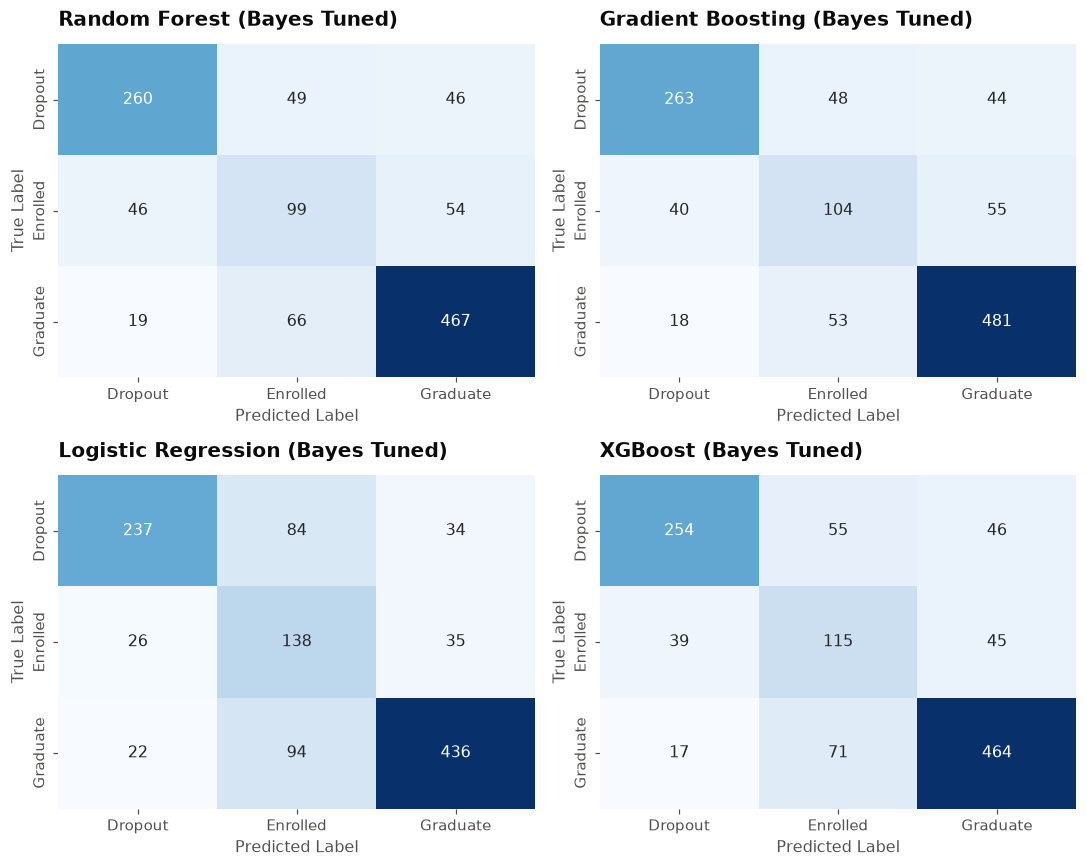

 FINAL BAYES TUNED LEADERBOARD (TEST SET) 
              Model  Test Accuracy  Test Macro-F1  Test ROC-AUC
  Gradient Boosting       0.766727       0.714260      0.889925
            XGBoost       0.753165       0.708313      0.885876
Logistic Regression       0.733273       0.700508      0.885229
      Random Forest       0.746835       0.692933      0.873454


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# Ensure test set variables are picked up correctly
X_test_use = X_test if 'X_test' in locals() else Xte
y_test_use = y_test if 'y_test' in locals() else yte

# ── Evaluate Tuned Models on Test Set ─────────────────────────────────────────
print("\n" + "=" * 65)
print(" BAYESIAN TUNED MODELS: TEST SET PERFORMANCE ")
print("=" * 65)

test_results = []
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# Get class labels from the encoder or just use unique values
class_names = LABEL_ENC.classes_ if 'LABEL_ENC' in locals() else np.unique(y_test_use)

for i, (model_name, bs) in enumerate(tuning_results.items()):
    # Get the best trained pipeline from BayesSearchCV
    best_model = bs.best_estimator_
    
    # Handle XGBoost target encoding difference
    if model_name == 'XGBoost':
        y_test_eval = LABEL_ENC.transform(y_test_use)
    else:
        y_test_eval = y_test_use
        
    # Predictions
    y_pred = best_model.predict(X_test_use)
    y_pred_proba = best_model.predict_proba(X_test_use)
    
    # Metrics
    acc = accuracy_score(y_test_eval, y_pred)
    f1 = f1_score(y_test_eval, y_pred, average='macro')
    roc_auc = roc_auc_score(y_test_eval, y_pred_proba, multi_class='ovr', average='macro')
    
    test_results.append({
        'Model': model_name,
        'Test Accuracy': acc,
        'Test Macro-F1': f1,
        'Test ROC-AUC': roc_auc
    })
    
    print(f"[{model_name}]")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Macro-F1 : {f1:.4f}")
    print(f"  ROC-AUC  : {roc_auc:.4f}\n")
    
    # Confusion Matrix Plot
    cm = confusion_matrix(y_test_eval, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    axes[i].set_title(f'{model_name} (Bayes Tuned)')
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# ── Final Test Set Summary Table ──────────────────────────────────────────────
print("=" * 65)
print(" FINAL BAYES TUNED LEADERBOARD (TEST SET) ")
print("=" * 65)
test_summary_df = pd.DataFrame(test_results).sort_values('Test Macro-F1', ascending=False).reset_index(drop=True)
print(test_summary_df.to_string(index=False))
print("=" * 65)

In [38]:
import time
import warnings
import numpy as np
import pandas as pd
import optuna

from sklearn.model_selection import cross_val_score
from sklearn.base import clone

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', module='category_encoders')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.ensemble import IsolationForest, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# ── Safety Checks ──────────────────────────────────────────────────────────────
RANDOM_STATE = 42 if 'RANDOM_STATE' not in locals() else RANDOM_STATE
CV_FOLDS     = 5  if 'CV_FOLDS' not in locals() else CV_FOLDS
LABEL_ENC = LabelEncoder().fit(y_train) if 'LABEL_ENC' not in locals() else LABEL_ENC

y_train_encoded = LABEL_ENC.transform(y_train)

# Set number of Optuna trials
N_TRIALS = 30 

# ── Rebuild Best Pipelines from Identified Steps ───────────────────────────────

# (1) Random Forest
keep_rf = IsolationForest(random_state=RANDOM_STATE).fit_predict(X_train) == 1
Xtr_rf, ytr_rf = X_train.iloc[keep_rf], y_train.iloc[keep_rf]

rf_base = ImbPipeline([
    ('prep',  build_preprocessor(Xtr_rf)),
    ('fs',    SelectKBest(mutual_info_classif)),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf',   RandomForestClassifier(class_weight='balanced_subsample',
                                     n_jobs=-1, random_state=RANDOM_STATE))
])

def rf_param_grid(trial):
    return {
        'clf__n_estimators': trial.suggest_int('clf__n_estimators', 200, 800),
        'clf__max_depth': trial.suggest_int('clf__max_depth', 5, 30),
        'clf__min_samples_leaf': trial.suggest_int('clf__min_samples_leaf', 1, 15),
        'fs__k': trial.suggest_int('fs__k', 10, 30)
    }

# (2) Gradient Boosting
gb_base = ImbPipeline([
    ('prep',  build_preprocessor(X_train)),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf',   HistGradientBoostingClassifier(class_weight='balanced',
                                             random_state=RANDOM_STATE))
])

def gb_param_grid(trial):
    return {
        'clf__max_iter': trial.suggest_int('clf__max_iter', 100, 500),
        'clf__learning_rate': trial.suggest_float('clf__learning_rate', 0.01, 0.3, log=True),
        'clf__max_leaf_nodes': trial.suggest_int('clf__max_leaf_nodes', 15, 127),
        'clf__min_samples_leaf': trial.suggest_int('clf__min_samples_leaf', 10, 50)
    }

# (3) Logistic Regression
lr_base = SkPipeline([
    ('prep', build_preprocessor(X_train)),
    ('clf',  LogisticRegression(penalty='l1', solver='saga', class_weight='balanced',
                                max_iter=5000, random_state=RANDOM_STATE))
])

def lr_param_grid(trial):
    return {
        'clf__C': trial.suggest_float('clf__C', 0.01, 20.0, log=True)
    }

# (4) XGBoost
xgb_base = ImbPipeline([
    ('prep',  build_preprocessor(X_train)),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf',   XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE))
])

def xgb_param_grid(trial):
    return {
        'clf__n_estimators': trial.suggest_int('clf__n_estimators', 100, 500),
        'clf__max_depth': trial.suggest_int('clf__max_depth', 3, 12),
        'clf__learning_rate': trial.suggest_float('clf__learning_rate', 0.01, 0.3, log=True),
        'clf__subsample': trial.suggest_float('clf__subsample', 0.5, 1.0)
    }

# ── Optuna Custom Tuner Class ─────────────────────────────────────────────────
# This perfectly mimics GridSearchCV so your plot code works seamlessly!

class OptunaTuner:
    def __init__(self, pipeline, param_def_func, X, y, cv, n_trials):
        self.pipeline = pipeline
        self.param_def_func = param_def_func
        self.X = X
        self.y = y
        self.cv = cv
        self.n_trials = n_trials
        self.best_estimator_ = None
        self.best_score_ = -float('inf')
        self.best_params_ = None

    def optimize(self):
        def objective(trial):
            params = self.param_def_func(trial)
            model = clone(self.pipeline)
            model.set_params(**params)
            
            # Evaluate using Cross Validation
            scores = cross_val_score(model, self.X, self.y, cv=self.cv, scoring='f1_macro', n_jobs=-1)
            return scores.mean()
            
        study = optuna.create_study(direction="maximize")
        study.optimize(objective, n_trials=self.n_trials)
        
        self.best_score_ = study.best_value
        self.best_params_ = study.best_params
        
        # Fit the absolute best model on the FULL training dataset
        self.best_estimator_ = clone(self.pipeline)
        self.best_estimator_.set_params(**self.best_params_)
        self.best_estimator_.fit(self.X, self.y)
        
        return self

# ── Run Optuna for Each Model ──────────────────────────────────────────────────
print(f"Starting Optuna Hyperparameter Tuning (n_trials={N_TRIALS})...")
print("=" * 65)

# Output variable is 'tuning_results' so the plots still work natively
tuning_results = {}

# -- Random Forest -----------------------------------------------------------
print("\n[1/4] Optuna Tuning: Random Forest")
t0 = time.time()
rf_opt = OptunaTuner(rf_base, rf_param_grid, Xtr_rf, ytr_rf, CV_FOLDS, N_TRIALS).optimize()
tuning_results['Random Forest'] = rf_opt
print(f"  Best CV macro-F1 : {rf_opt.best_score_:.4f}  ({time.time()-t0:.0f}s)")
print(f"  Best params      : {rf_opt.best_params_}")

# -- Gradient Boosting -------------------------------------------------------
print("\n[2/4] Optuna Tuning: Gradient Boosting")
t0 = time.time()
gb_opt = OptunaTuner(gb_base, gb_param_grid, X_train, y_train, CV_FOLDS, N_TRIALS).optimize()
tuning_results['Gradient Boosting'] = gb_opt
print(f"  Best CV macro-F1 : {gb_opt.best_score_:.4f}  ({time.time()-t0:.0f}s)")
print(f"  Best params      : {gb_opt.best_params_}")

# -- Logistic Regression -----------------------------------------------------
print("\n[3/4] Optuna Tuning: Logistic Regression")
t0 = time.time()
lr_opt = OptunaTuner(lr_base, lr_param_grid, X_train, y_train, CV_FOLDS, N_TRIALS).optimize()
tuning_results['Logistic Regression'] = lr_opt
print(f"  Best CV macro-F1 : {lr_opt.best_score_:.4f}  ({time.time()-t0:.0f}s)")
print(f"  Best params      : {lr_opt.best_params_}")

# -- XGBoost -----------------------------------------------------------------
print("\n[4/4] Optuna Tuning: XGBoost")
t0 = time.time()
xgb_opt = OptunaTuner(xgb_base, xgb_param_grid, X_train, y_train_encoded, CV_FOLDS, N_TRIALS).optimize()
tuning_results['XGBoost'] = xgb_opt
print(f"  Best CV macro-F1 : {xgb_opt.best_score_:.4f}  ({time.time()-t0:.0f}s)")
print(f"  Best params      : {xgb_opt.best_params_}")

# ── Summary Table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print(" OPTUNA TUNING SUMMARY ")
print("=" * 65)
optuna_summary = pd.DataFrame([
    {'Model': name, 'Best CV Macro-F1': opt.best_score_, 'Best Params': opt.best_params_}
    for name, opt in tuning_results.items()
]).sort_values('Best CV Macro-F1', ascending=False).reset_index(drop=True)

print(optuna_summary[['Model', 'Best CV Macro-F1']].to_string(index=False))
print("=" * 65)

Starting Optuna Hyperparameter Tuning (n_trials=30)...

[1/4] Optuna Tuning: Random Forest
  Best CV macro-F1 : 0.7008  (250s)
  Best params      : {'clf__n_estimators': 268, 'clf__max_depth': 30, 'clf__min_samples_leaf': 10, 'fs__k': 29}

[2/4] Optuna Tuning: Gradient Boosting
  Best CV macro-F1 : 0.7164  (828s)
  Best params      : {'clf__max_iter': 443, 'clf__learning_rate': 0.025714343325487006, 'clf__max_leaf_nodes': 47, 'clf__min_samples_leaf': 13}

[3/4] Optuna Tuning: Logistic Regression
  Best CV macro-F1 : 0.7127  (696s)
  Best params      : {'clf__C': 0.7294613086577313}

[4/4] Optuna Tuning: XGBoost
  Best CV macro-F1 : 0.7226  (332s)
  Best params      : {'clf__n_estimators': 337, 'clf__max_depth': 3, 'clf__learning_rate': 0.046424548768528855, 'clf__subsample': 0.8272764436986019}

 OPTUNA TUNING SUMMARY 
              Model  Best CV Macro-F1
            XGBoost          0.722591
  Gradient Boosting          0.716403
Logistic Regression          0.712748
      Random Fore


 OPTUNA TUNED MODELS: TEST SET PERFORMANCE 
[Random Forest]
  Accuracy : 0.7405
  Macro-F1 : 0.6963
  ROC-AUC  : 0.8737

[Gradient Boosting]
  Accuracy : 0.7658
  Macro-F1 : 0.7108
  ROC-AUC  : 0.8830

[Logistic Regression]
  Accuracy : 0.7324
  Macro-F1 : 0.6998
  ROC-AUC  : 0.8852

[XGBoost]
  Accuracy : 0.7631
  Macro-F1 : 0.7129
  ROC-AUC  : 0.8883



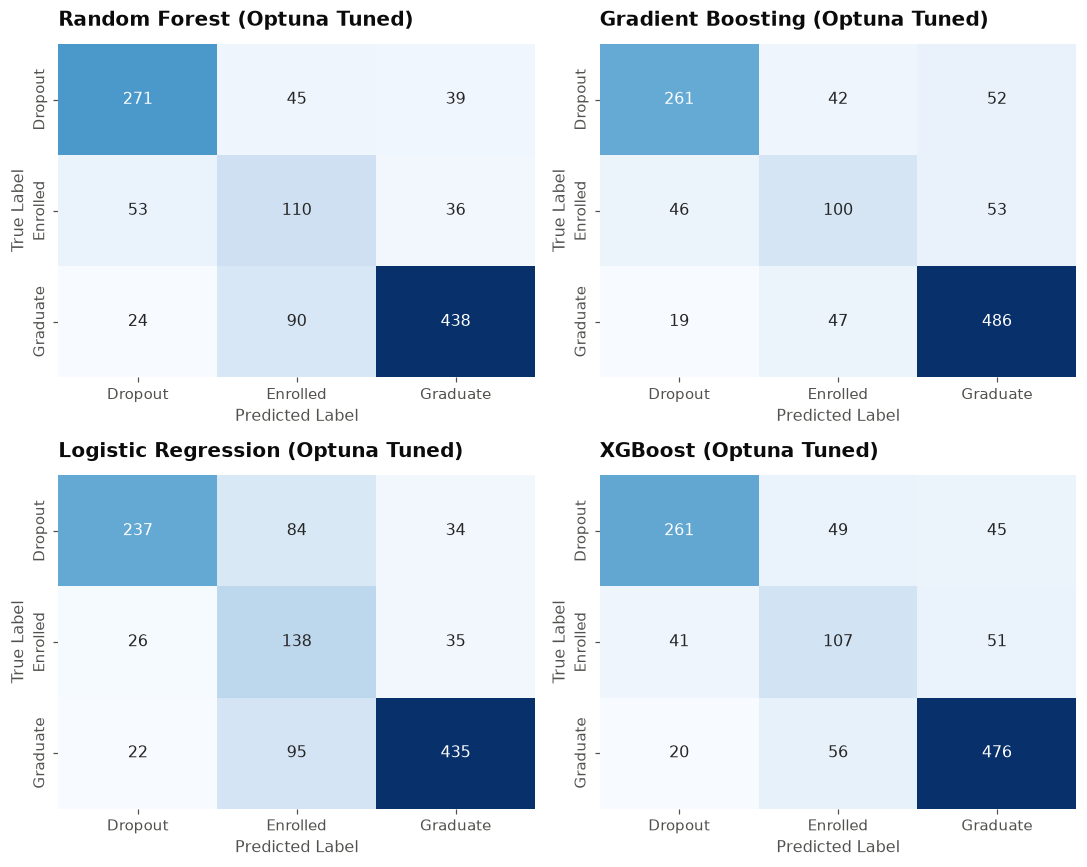

 FINAL OPTUNA TUNED LEADERBOARD (TEST SET) 
              Model  Test Accuracy  Test Macro-F1  Test ROC-AUC
            XGBoost       0.763110       0.712902      0.888310
  Gradient Boosting       0.765823       0.710792      0.883048
Logistic Regression       0.732369       0.699791      0.885213
      Random Forest       0.740506       0.696337      0.873738


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# Ensure test set variables are picked up correctly
X_test_use = X_test if 'X_test' in locals() else Xte
y_test_use = y_test if 'y_test' in locals() else yte

# ── Evaluate Tuned Models on Test Set ─────────────────────────────────────────
print("\n" + "=" * 65)
print(" OPTUNA TUNED MODELS: TEST SET PERFORMANCE ")
print("=" * 65)

test_results = []
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# Get class labels from the encoder or just use unique values
class_names = LABEL_ENC.classes_ if 'LABEL_ENC' in locals() else np.unique(y_test_use)

for i, (model_name, opt_result) in enumerate(tuning_results.items()):
    # Get the best trained pipeline saved from Optuna
    best_model = opt_result.best_estimator_
    
    # Handle XGBoost target encoding difference
    if model_name == 'XGBoost':
        y_test_eval = LABEL_ENC.transform(y_test_use)
    else:
        y_test_eval = y_test_use
        
    # Predictions
    y_pred = best_model.predict(X_test_use)
    y_pred_proba = best_model.predict_proba(X_test_use)
    
    # Metrics
    acc = accuracy_score(y_test_eval, y_pred)
    f1 = f1_score(y_test_eval, y_pred, average='macro')
    roc_auc = roc_auc_score(y_test_eval, y_pred_proba, multi_class='ovr', average='macro')
    
    test_results.append({
        'Model': model_name,
        'Test Accuracy': acc,
        'Test Macro-F1': f1,
        'Test ROC-AUC': roc_auc
    })
    
    print(f"[{model_name}]")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Macro-F1 : {f1:.4f}")
    print(f"  ROC-AUC  : {roc_auc:.4f}\n")
    
    # Confusion Matrix Plot
    cm = confusion_matrix(y_test_eval, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    axes[i].set_title(f'{model_name} (Optuna Tuned)')
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# ── Final Test Set Summary Table ──────────────────────────────────────────────
print("=" * 65)
print(" FINAL OPTUNA TUNED LEADERBOARD (TEST SET) ")
print("=" * 65)
test_summary_df = pd.DataFrame(test_results).sort_values('Test Macro-F1', ascending=False).reset_index(drop=True)
print(test_summary_df.to_string(index=False))
print("=" * 65)

 TOP MODEL IDENTIFIED FOR EACH TUNING METHOD (By Training CV Score)
     GridSearch: XGBoost
    BayesSearch: XGBoost
         Optuna: XGBoost



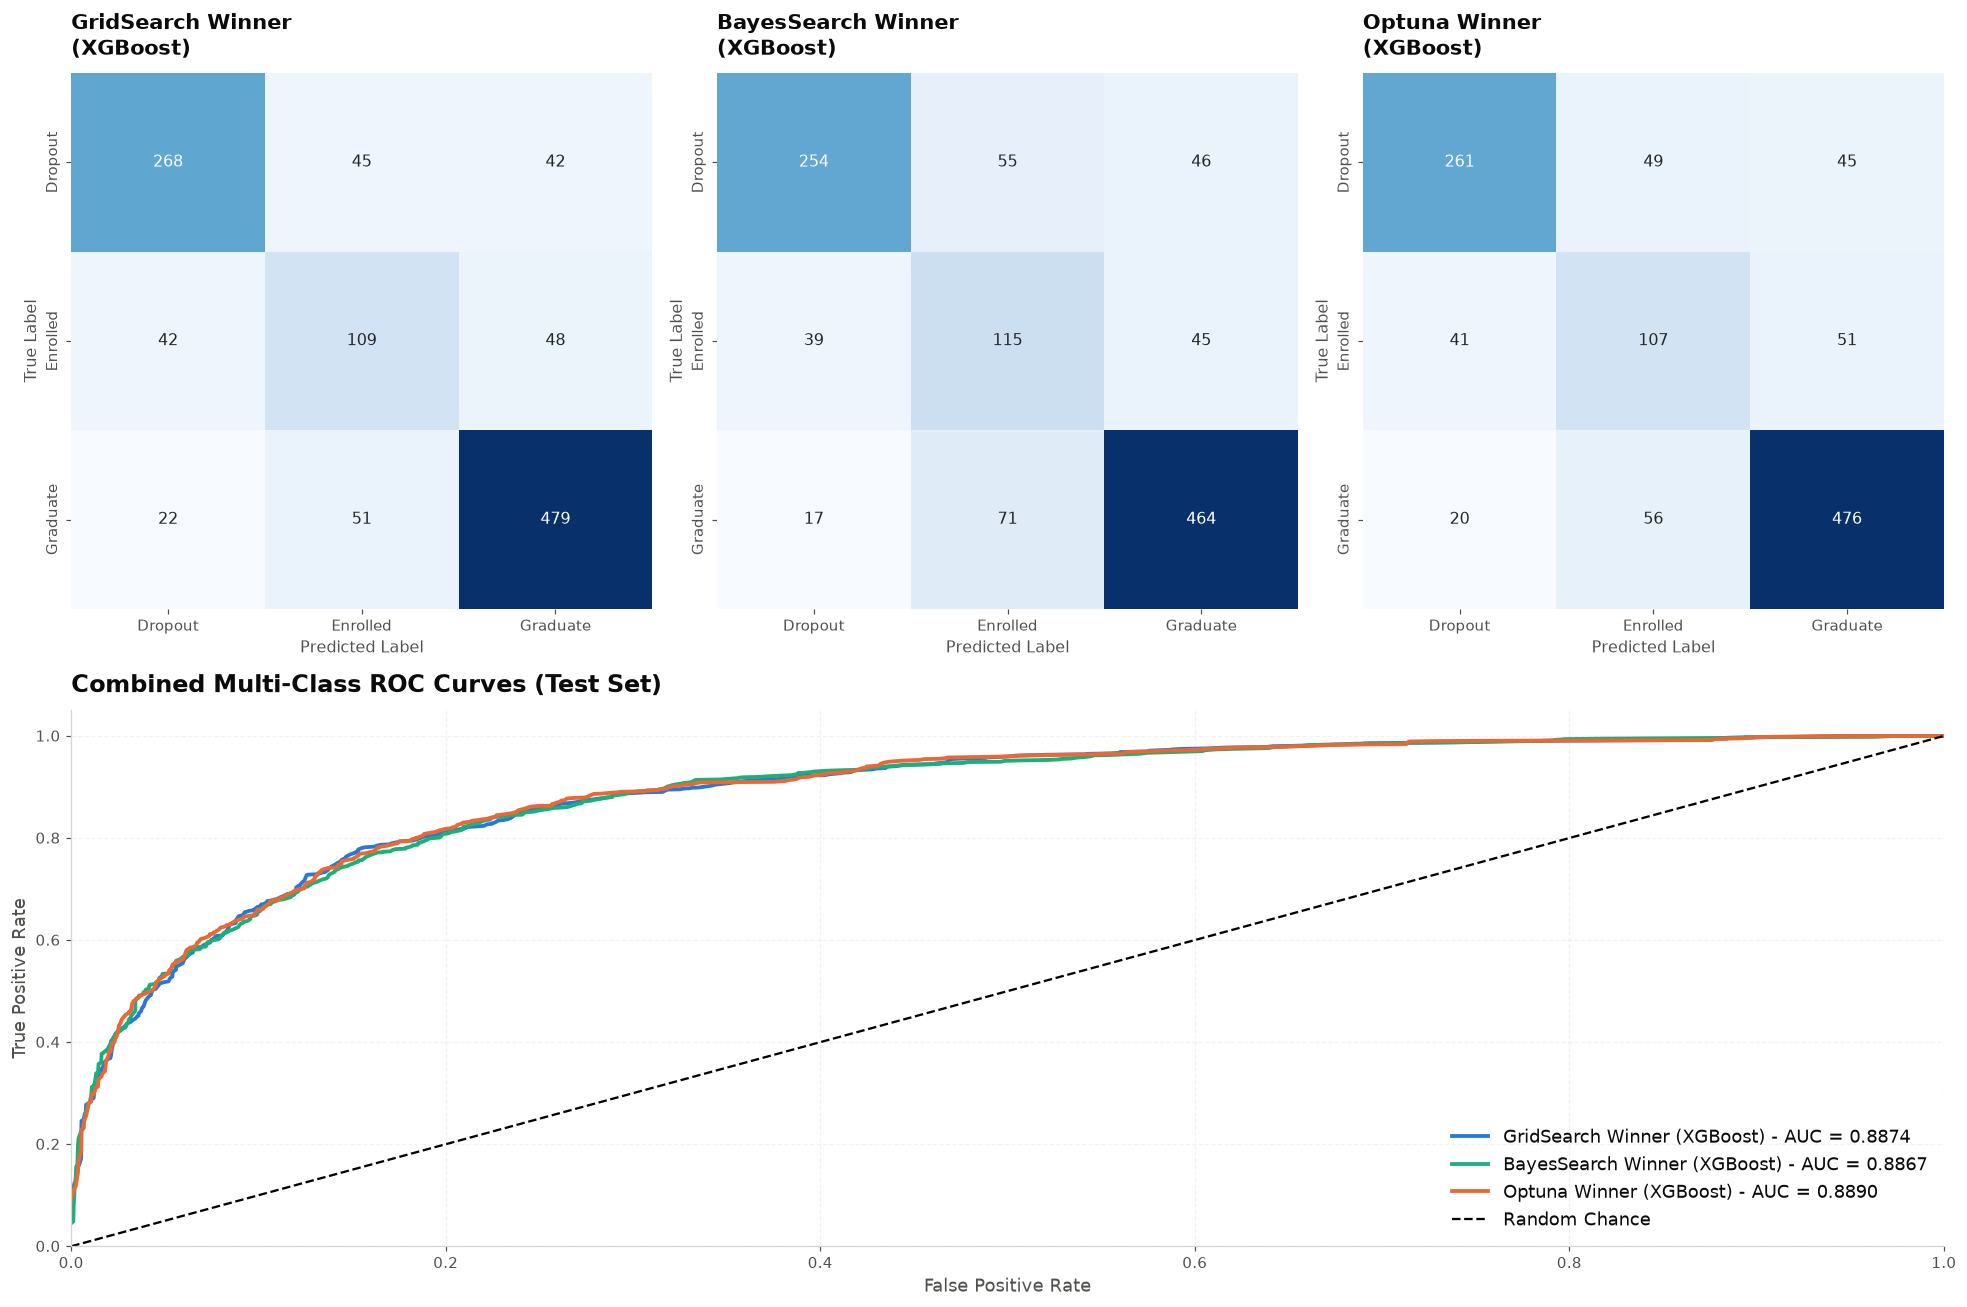

 ULTIMATE COMPARISON: TEST SET PERFORMANCE 
Tuning Method Best Model  Test Accuracy  Test Macro-F1
   GridSearch    XGBoost       0.773960       0.724801
       Optuna    XGBoost       0.763110       0.712902
  BayesSearch    XGBoost       0.753165       0.708313


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Ensure test set variables are picked up correctly
X_test_use = X_test if 'X_test' in locals() else Xte
y_test_use = y_test if 'y_test' in locals() else yte

class_names = LABEL_ENC.classes_ if 'LABEL_ENC' in locals() else np.unique(y_test_use)

# ── 1. Gather all models from memory ──────────────────────────────────────────
# Since we used distinct variable names for each tuning method, we can collect them:
grid_search_models = {'Random Forest': rf_gs, 'Gradient Boosting': gb_gs, 'Logistic Regression': lr_gs, 'XGBoost': xgb_gs}
bayes_search_models = {'Random Forest': rf_bs, 'Gradient Boosting': gb_bs, 'Logistic Regression': lr_bs, 'XGBoost': xgb_bs}
optuna_models = {'Random Forest': rf_opt, 'Gradient Boosting': gb_opt, 'Logistic Regression': lr_opt, 'XGBoost': xgb_opt}

# ── 2. Find the Absolute Best Model for Each Method (based on CV score) ───────
best_gs_name = max(grid_search_models, key=lambda k: grid_search_models[k].best_score_)
best_bs_name = max(bayes_search_models, key=lambda k: bayes_search_models[k].best_score_)
best_opt_name = max(optuna_models, key=lambda k: optuna_models[k].best_score_)

top_models = {
    'GridSearch': (best_gs_name, grid_search_models[best_gs_name].best_estimator_),
    'BayesSearch': (best_bs_name, bayes_search_models[best_bs_name].best_estimator_),
    'Optuna': (best_opt_name, optuna_models[best_opt_name].best_estimator_)
}

print("=" * 70)
print(" TOP MODEL IDENTIFIED FOR EACH TUNING METHOD (By Training CV Score)")
print("=" * 70)
for method, (model_name, _) in top_models.items():
    print(f"{method:>15}: {model_name}")
print("=" * 70 + "\n")

# ── 3. Helper for Macro-Average ROC Curve (Multi-class) ───────────────────────
def get_macro_roc(y_true, y_proba, classes_idx):
    y_bin = label_binarize(y_true, classes=classes_idx)
    n_classes = y_bin.shape[1]
    
    fpr = dict()
    tpr = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_proba[:, i])
        
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)
    return all_fpr, mean_tpr, macro_auc

# ── 4. Evaluate and Plot ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
# Top row for Confusion Matrices (3 subplots side-by-side)
ax_cm_gs = plt.subplot2grid((2, 3), (0, 0))
ax_cm_bs = plt.subplot2grid((2, 3), (0, 1))
ax_cm_opt = plt.subplot2grid((2, 3), (0, 2))
cm_axes = [ax_cm_gs, ax_cm_bs, ax_cm_opt]

# Bottom row for a single combined ROC curve
ax_roc = plt.subplot2grid((2, 3), (1, 0), colspan=3)

colors = {'GridSearch': '#2a78d6', 'BayesSearch': '#1baf7a', 'Optuna': '#eb6834'}
test_results = []

for i, (method_name, (model_name, best_model)) in enumerate(top_models.items()):
    
    # Handle XGBoost target encoding difference
    if model_name == 'XGBoost':
        y_test_eval = LABEL_ENC.transform(y_test_use)
        classes_idx = np.unique(y_test_eval)
    else:
        y_test_eval = y_test_use
        classes_idx = np.unique(y_test_use)
        
    # Predictions
    y_pred = best_model.predict(X_test_use)
    y_proba = best_model.predict_proba(X_test_use)
    
    # Metrics
    acc = accuracy_score(y_test_eval, y_pred)
    f1 = f1_score(y_test_eval, y_pred, average='macro')
    
    test_results.append({
        'Tuning Method': method_name,
        'Best Model': model_name,
        'Test Accuracy': acc,
        'Test Macro-F1': f1
    })
    
    # ── Confusion Matrix 
    cm = confusion_matrix(y_test_eval, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=cm_axes[i], cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    cm_axes[i].set_title(f"{method_name} Winner\n({model_name})", fontsize=14, fontweight='bold')
    cm_axes[i].set_ylabel('True Label')
    cm_axes[i].set_xlabel('Predicted Label')
    
    # ── ROC Curve (Macro) 
    fpr, tpr, roc_auc = get_macro_roc(y_test_eval, y_proba, classes_idx)
    ax_roc.plot(fpr, tpr, color=colors[method_name], lw=2.5, 
                label=f"{method_name} Winner ({model_name}) - AUC = {roc_auc:.4f}")

# Finalize Combined ROC Plot
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance')
ax_roc.set_xlim([0.0, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_roc.set_xlabel('False Positive Rate', fontsize=12)
ax_roc.set_ylabel('True Positive Rate', fontsize=12)
ax_roc.set_title('Combined Multi-Class ROC Curves (Test Set)', fontsize=16, fontweight='bold')
ax_roc.legend(loc="lower right", fontsize=12)
ax_roc.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ── 5. Final Summary Table ────────────────────────────────────────────────────
print("=" * 70)
print(" ULTIMATE COMPARISON: TEST SET PERFORMANCE ")
print("=" * 70)
test_summary_df = pd.DataFrame(test_results).sort_values('Test Macro-F1', ascending=False).reset_index(drop=True)
print(test_summary_df.to_string(index=False))
print("=" * 70)

In [47]:
import os
import joblib

# 1. Define the directory path and ensure the folder actually exists
model_dir = "/home/chandima-bandara/Desktop/student-retention-analysis/models"
os.makedirs(model_dir, exist_ok=True)

# 2. Extract the absolute best GridSearch XGBoost model
# We pull it directly from the 'xgb_gs' variable created during the GridSearch step
final_xgboost_model = xgb_gs.best_estimator_

# 3. Save the main Pipeline model
model_path = os.path.join(model_dir, "final_xgboost_model.joblib")
joblib.dump(final_xgboost_model, model_path)
print(f"✅ Final XGBoost Pipeline saved successfully to:\n   {model_path}\n")

# 4. Save the Label Encoder
# CRITICAL: You must save this to decode the predictions later!
encoder_path = os.path.join(model_dir, "target_label_encoder.joblib")
joblib.dump(LABEL_ENC, encoder_path)
print(f"✅ Target Label Encoder saved successfully to:\n   {encoder_path}")

✅ Final XGBoost Pipeline saved successfully to:
   /home/chandima-bandara/Desktop/student-retention-analysis/models/final_xgboost_model.joblib

✅ Target Label Encoder saved successfully to:
   /home/chandima-bandara/Desktop/student-retention-analysis/models/target_label_encoder.joblib
